# Кредитный скоринг Home Credit

В этом проекте я проверяю, насколько хорошо можно предсказывать риск дефолта по данным заявки. Сначала использую только `application_train`: анкету клиента и признаки, доступные в основной таблице, без `bureau`, прошлых заявок и платёжных таблиц. Это приближённый сценарий для клиента без накопленной истории внутри Home Credit.

Затем добавляю подробную кредитную и платёжную историю и смотрю, насколько она улучшает качество при той же модели и той же 5-fold валидации.

Для сравнения использую логистическую регрессию, решающее дерево, LightGBM, CatBoost и MLP на данных **Home Credit Default Risk**.

> `EXT_SOURCE_*` находятся уже в основной таблице и являются внешними скоринговыми признаками. Поэтому вариант «только заявка» нельзя трактовать как гарантированное отсутствие любой внешней кредитной информации — это именно сценарий без подробных исторических таблиц Home Credit.

## Что буду делать

Иду от простого к сложному. Сначала посмотрю на данные и основные проблемы: баланс классов, пропуски, аномальные значения и покрытие кредитной истории. После EDA сделаю несколько понятных признаков из анкеты и обучу простые baseline-модели.

Дальше соберу признаки из дополнительных таблиц и повторю эксперимент уже на полной истории клиента. В конце сравню модели на одинаковой 5-fold валидации, попробую смешать их прогнозы и отдельно посмотрю SHAP, различия качества по полу и возрасту и типичные ошибки модели.

## Как буду оценивать модели

`TARGET=1` означает, что у клиента были сложности с выплатой кредита. Положительный класс редкий, поэтому accuracy здесь малоинформативна. Основная метрика — **ROC-AUC**, как и в соревновании Kaggle. Дополнительно смотрю PR-AUC и Brier score.

Чтобы итоговая таблица закрывала стандартные классификационные метрики, также считаю accuracy и F1 при одном фиксированном пороге 0.5. Для выбора лучшей модели их не использую: при таком дисбалансе они сильно зависят от порога. Отдельный OOF-порог по максимуму F1 нужен только для разбора ошибок и fairness-диагностики.

Все модели сравниваю на одних и тех же пяти стратифицированных фолдах. Тестовый набор Kaggle в оценке качества не участвует.

Перед началом есть несколько простых гипотез: внешние скоринги и кредитная история должны быть полезны; отношения кредита к доходу и аннуитета к доходу могут быть информативнее абсолютных сумм; пропуски сами по себе могут нести сигнал; деревья должны лучше линейной модели улавливать нелинейные зависимости.

## 1. Подготовка

Ноутбук можно запускать локально или на Kaggle. Локально данные ожидаются в `data/raw/`. `FAST_MODE=True` оставил для быстрой проверки кода; итоговые результаты нужно считать на полном датасете.

In [24]:
from pathlib import Path
from time import perf_counter
import gc
import json
import random
import warnings

import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
import pandas as pd
import seaborn as sns
import torch

from IPython.display import display, Markdown

RANDOM_STATE = 2026
KAGGLE_INPUT_ROOT = Path('/kaggle/input')
ON_KAGGLE = KAGGLE_INPUT_ROOT.exists()
REQUIRED_DATA_FILES = {
    'application_train.csv',
    'application_test.csv',
    'bureau.csv',
    'bureau_balance.csv',
    'previous_application.csv',
    'POS_CASH_balance.csv',
    'installments_payments.csv',
    'credit_card_balance.csv',
}


def resolve_project_root() -> Path:
    current = Path.cwd().resolve()
    candidates = [current, current.parent]
    for candidate in candidates:
        if (candidate / 'data' / 'raw').exists():
            return candidate
    raise FileNotFoundError(
        'Не найдена папка data/raw. Откройте notebook из проекта '
        'или разместите данные в data/raw/.'
    )


def resolve_data_dir() -> Path:
    if not ON_KAGGLE:
        return PROJECT_ROOT / 'data' / 'raw'

    candidates = sorted(
        {
            csv_path.parent
            for csv_path in KAGGLE_INPUT_ROOT.rglob('application_train.csv')
            if REQUIRED_DATA_FILES.issubset(
                {path.name for path in csv_path.parent.glob('*.csv')}
            )
        },
        key=lambda path: str(path),
    )
    if not candidates:
        raise FileNotFoundError(
            'На Kaggle добавьте Input Home Credit Default Risk '
            '(Competition Data).'
        )
    return candidates[0]


PROJECT_ROOT = None if ON_KAGGLE else resolve_project_root()
DATA_DIR = resolve_data_dir()
OUTPUT_DIR = (
    Path('/kaggle/working/home_credit_scoring')
    if ON_KAGGLE
    else PROJECT_ROOT
)
REPORTS_DIR = OUTPUT_DIR / 'reports'
FIGURES_DIR = REPORTS_DIR / 'figures'
SUBMISSIONS_DIR = OUTPUT_DIR / 'submissions'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
SUBMISSIONS_DIR.mkdir(parents=True, exist_ok=True)

# Полная конфигурация эксперимента: notebook рассчитан на запуск на GPU.
FAST_MODE = False
FAST_NROWS = 250_000
N_SPLITS = 5
RUN_FULL_COMPETITIVE_EXPERIMENT = True
FULL_OPTUNA_TRIALS = 40
RUN_SHAP_AND_FAIRNESS = True
RUN_ABLATION_STUDY = True
RUN_ERROR_ANALYSIS = True

CUDA_AVAILABLE = torch.cuda.is_available()
if not CUDA_AVAILABLE:
    raise RuntimeError(
        'Для полного запуска нужен доступный GPU. Выберите Python kernel с CUDA '
        'или включите GPU в настройках Kaggle.'
    )
USE_GPU = True
# Для Linux используется CUDA-реализация LightGBM из conda-forge.
LGBM_DEVICE_TYPE = 'cuda'
LGBM_DEVICE_PARAMS = {'device_type': LGBM_DEVICE_TYPE}
LGBM_N_JOBS = 4

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 160)
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')
sns.set_theme(style='whitegrid', context='notebook', palette='deep')

for font_path in [
    Path(r'C:\Windows\Fonts\arial.ttf'),
    Path('/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf'),
]:
    if font_path.exists():
        font_manager.fontManager.addfont(str(font_path))
        plt.rcParams['font.family'] = font_manager.FontProperties(
            fname=str(font_path)
        ).get_name()
        break
plt.rcParams['axes.unicode_minus'] = False

assert N_SPLITS >= 5, 'По заданию требуется не менее 5 CV-фолдов.'
assert REQUIRED_DATA_FILES.issubset(
    {path.name for path in DATA_DIR.glob('*.csv')}
), 'В data/raw отсутствуют файлы соревнования.'
print(f'Среда: {"Kaggle" if ON_KAGGLE else "локальная"}')
print(f'Режим: полный GPU; folds={N_SPLITS}; Optuna trials={FULL_OPTUNA_TRIALS}')
print('CUDA:', torch.cuda.get_device_name(0))
print(f'LightGBM device={LGBM_DEVICE_TYPE}; n_jobs={LGBM_N_JOBS}')


Среда: локальная
Режим: полный GPU; folds=5; Optuna trials=40
CUDA: NVIDIA GeForce RTX 5090
LightGBM device=cuda; n_jobs=4


## 2. Знакомство с данными

### 2.1. Что лежит в исходных файлах

Сначала проверяю основной train: сколько заявок, уникальны ли `SK_ID_CURR`, как распределён `TARGET` и нет ли очевидных технических значений. До построения моделей лучше сразу поймать проблемы, которые потом могут исказить валидацию.

In [25]:
raw_files = (
    pd.DataFrame([{'file': path.name, 'size_mb': path.stat().st_size / 1024**2} for path in sorted(DATA_DIR.glob('*.csv'))])
    .sort_values('size_mb', ascending=False).reset_index(drop=True)
)
display(raw_files.style.format({'size_mb': '{:.1f}'}).set_caption('Файлы исходной поставки'))

application_train = pd.read_csv(DATA_DIR / 'application_train.csv')
application_test = pd.read_csv(DATA_DIR / 'application_test.csv')
profile = pd.Series({
    'Строк в train': len(application_train), 'Столбцов в train': application_train.shape[1],
    'Строк в test': len(application_test), 'Столбцов в test': application_test.shape[1],
    'Дубликатов SK_ID_CURR в train': application_train['SK_ID_CURR'].duplicated().sum(),
    'Доля TARGET=1': application_train['TARGET'].mean(),
    'Технический DAYS_EMPLOYED=365243': (application_train['DAYS_EMPLOYED'] == 365243).sum(),
})
display(profile.to_frame('значение'))
assert application_train['SK_ID_CURR'].is_unique, 'Нарушена уникальность заявок в train'
assert application_test['SK_ID_CURR'].is_unique, 'Нарушена уникальность заявок в test'
assert set(application_train.columns) - {'TARGET'} == set(application_test.columns), 'Схемы train/test различаются'
print('Базовые проверки гранулярности и схемы пройдены.')

,file,size_mb
0,installments_payments.csv,689.6
1,credit_card_balance.csv,404.9
2,previous_application.csv,386.2
3,POS_CASH_balance.csv,374.5
4,bureau_balance.csv,358.2
5,bureau.csv,162.1
6,application_train.csv,158.4
7,application_test.csv,25.3
8,sample_submission.csv,0.5
9,HomeCredit_columns_description.csv,0.0


,значение
Строк в train,"307,511.0000"
Столбцов в train,122.0000
Строк в test,"48,744.0000"
Столбцов в test,121.0000
Дубликатов SK_ID_CURR в train,0.0000
Доля TARGET=1,0.0807
Технический DAYS_EMPLOYED=365243,"55,374.0000"


Базовые проверки гранулярности и схемы пройдены.


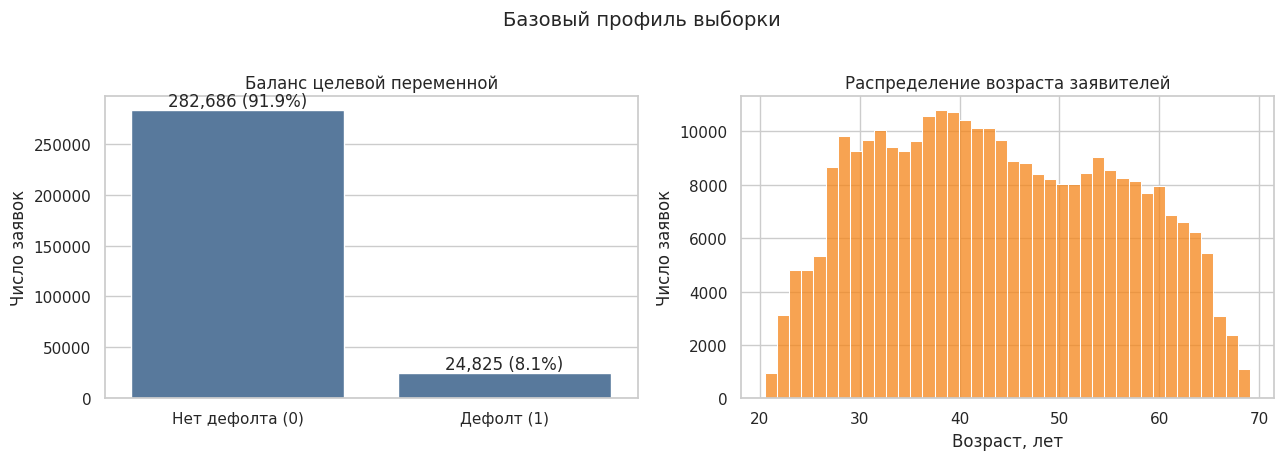

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
target_counts = application_train['TARGET'].value_counts().sort_index()
sns.barplot(x=['Нет дефолта (0)', 'Дефолт (1)'], y=target_counts.values, ax=axes[0], color='#4C78A8')
axes[0].set(title='Баланс целевой переменной', xlabel='', ylabel='Число заявок')
for i, value in enumerate(target_counts.values):
    axes[0].text(i, value, f'{value:,} ({value / len(application_train):.1%})', ha='center', va='bottom')
age = -application_train['DAYS_BIRTH'] / 365.25
sns.histplot(age, bins=40, color='#F58518', ax=axes[1])
axes[1].set(title='Распределение возраста заявителей', xlabel='Возраст, лет', ylabel='Число заявок')
fig.suptitle('Базовый профиль выборки', y=1.02, fontsize=14)
fig.tight_layout()
fig.savefig(FIGURES_DIR / '01_target_and_age.png', dpi=160, bbox_inches='tight')
plt.show()

**Что видно сразу.** Дефолтов около 8%, поэтому accuracy легко получить высокой даже у бесполезной модели. Ещё в данных есть четыре значения пола `XNA` и 55 374 значения `DAYS_EMPLOYED=365243`. Последнее явно не реальный стаж, поэтому дальше заменяю его на пропуск и добавляю отдельный флаг.

### 2.2. Пропуски, выбросы и аномальные значения

Дальше смотрю пропуски, распределения и экстремальные значения. Разреженные колонки не удаляю автоматически: отсутствие внешнего скоринга, сведений о жилье или кредитной истории само может быть сигналом.

Правдоподобные большие суммы дохода, кредита и аннуитета тоже не удаляю только потому, что они попали в хвост распределения. Для денежных признаков дальше добавляю `log1p`, чтобы уменьшить влияние длинных хвостов на линейную модель и MLP. Явное техническое значение `DAYS_EMPLOYED=365243` обрабатываю отдельно: заменяю на пропуск и сохраняю флаг аномалии.

In [27]:
feature_types = application_train.drop(columns='TARGET').dtypes.value_counts().rename_axis('dtype').reset_index(name='n_features')
display(feature_types)
missingness = application_train.drop(columns='TARGET').isna().mean().sort_values(ascending=False).rename('missing_rate').to_frame()
missingness['missing_count'] = (missingness['missing_rate'] * len(application_train)).round().astype(int)
display(missingness.head(20).style.format({'missing_rate': '{:.1%}'}).set_caption('20 признаков с наибольшей долей пропусков'))
key_numeric = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'DAYS_EMPLOYED', 'DAYS_BIRTH']
display(application_train[key_numeric].describe(percentiles=[.01, .05, .5, .95, .99]).T)
quality_checks = pd.DataFrame({
    'check': ['Отрицательный доход', 'Нулевой/отрицательный кредит', 'Нулевой/отрицательный аннуитет', 'Возраст < 18', 'Возраст > 100', 'XNA в CODE_GENDER'],
    'count': [(application_train['AMT_INCOME_TOTAL'] <= 0).sum(), (application_train['AMT_CREDIT'] <= 0).sum(), (application_train['AMT_ANNUITY'].fillna(1) <= 0).sum(), ((-application_train['DAYS_BIRTH'] / 365.25) < 18).sum(), ((-application_train['DAYS_BIRTH'] / 365.25) > 100).sum(), (application_train['CODE_GENDER'] == 'XNA').sum()],
})
quality_checks['rate'] = quality_checks['count'] / len(application_train)
display(quality_checks.style.format({'rate': '{:.3%}'}))

,dtype,n_features
0,float64,65
1,int64,40
2,object,16


,missing_rate,missing_count
COMMONAREA_AVG,69.9%,214865
COMMONAREA_MEDI,69.9%,214865
COMMONAREA_MODE,69.9%,214865
NONLIVINGAPARTMENTS_AVG,69.4%,213514
NONLIVINGAPARTMENTS_MEDI,69.4%,213514
NONLIVINGAPARTMENTS_MODE,69.4%,213514
FONDKAPREMONT_MODE,68.4%,210295
LIVINGAPARTMENTS_MEDI,68.4%,210199
LIVINGAPARTMENTS_AVG,68.4%,210199
LIVINGAPARTMENTS_MODE,68.4%,210199


,count,mean,std,min,1%,5%,50%,95%,99%,max
AMT_INCOME_TOTAL,"307,511.0000","168,797.9193","237,123.1463","25,650.0000","45,000.0000","67,500.0000","147,150.0000","337,500.0000","472,500.0000","117,000,000.0000"
AMT_CREDIT,"307,511.0000","599,025.9997","402,490.7770","45,000.0000","76,410.0000","135,000.0000","513,531.0000","1,350,000.0000","1,854,000.0000","4,050,000.0000"
AMT_ANNUITY,"307,499.0000","27,108.5739","14,493.7373","1,615.5000","6,182.9100","9,000.0000","24,903.0000","53,325.0000","70,006.5000","258,025.5000"
DAYS_EMPLOYED,"307,511.0000","63,815.0459","141,275.7665","-17,912.0000","-10,894.9000","-6,742.5000","-1,213.0000","365,243.0000","365,243.0000","365,243.0000"
DAYS_BIRTH,"307,511.0000","-16,036.9951","4,363.9886","-25,229.0000","-24,419.0000","-23,204.0000","-15,750.0000","-9,407.0000","-8,263.0000","-7,489.0000"


,check,count,rate
0,Отрицательный доход,0,0.000%
1,Нулевой/отрицательный кредит,0,0.000%
2,Нулевой/отрицательный аннуитет,0,0.000%
3,Возраст < 18,0,0.000%
4,Возраст > 100,0,0.000%
5,XNA в CODE_GENDER,4,0.001%


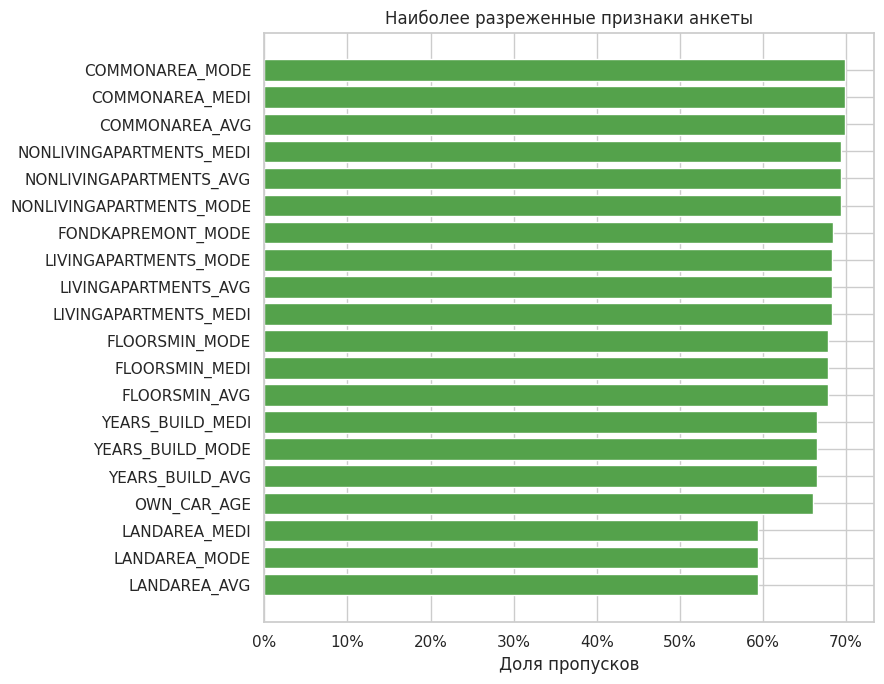

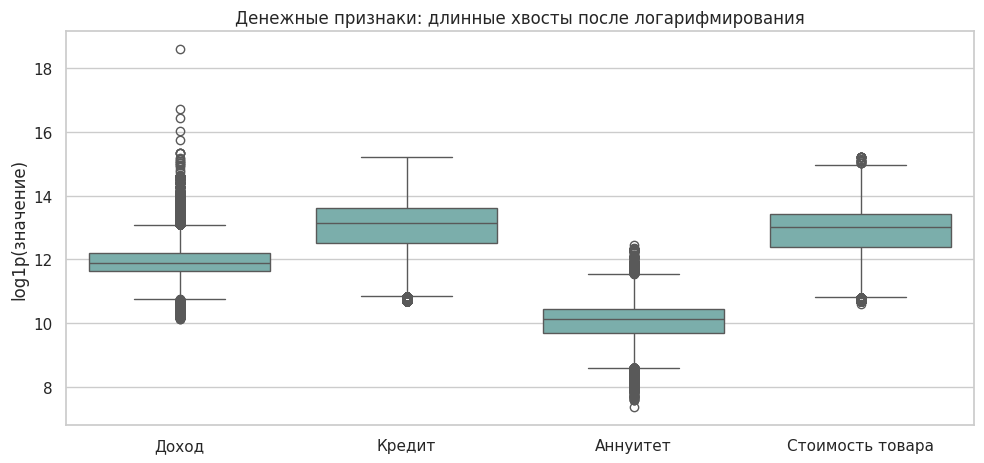

In [28]:
top_missing = missingness.head(20).sort_values('missing_rate')
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top_missing.index, top_missing['missing_rate'], color='#54A24B')
ax.set(title='Наиболее разреженные признаки анкеты', xlabel='Доля пропусков', ylabel='')
ax.xaxis.set_major_formatter(lambda x, pos: f'{x:.0%}')
fig.tight_layout()
fig.savefig(FIGURES_DIR / '02_missingness.png', dpi=160, bbox_inches='tight')
plt.show()

# Boxplot нужен не только формально: он показывает длинные хвосты денежных признаков.
amount_columns = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']
amounts_long = (
    np.log1p(application_train[amount_columns].clip(lower=0))
    .rename(columns={
        'AMT_INCOME_TOTAL': 'Доход',
        'AMT_CREDIT': 'Кредит',
        'AMT_ANNUITY': 'Аннуитет',
        'AMT_GOODS_PRICE': 'Стоимость товара',
    })
    .melt(var_name='Признак', value_name='log1p(значение)')
)
fig, ax = plt.subplots(figsize=(10, 4.8))
sns.boxplot(data=amounts_long, x='Признак', y='log1p(значение)', ax=ax, color='#72B7B2')
ax.set(title='Денежные признаки: длинные хвосты после логарифмирования', xlabel='', ylabel='log1p(значение)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / '02b_amount_boxplots.png', dpi=160, bbox_inches='tight')
plt.show()


### 2.3. Какие признаки связаны с дефолтом

Теперь смотрю несколько понятных зависимостей: возраст, доход, размер кредита и внешние скоринги. Эти графики нужны не для причинных выводов, а чтобы понять, какие преобразования стоит проверить дальше.

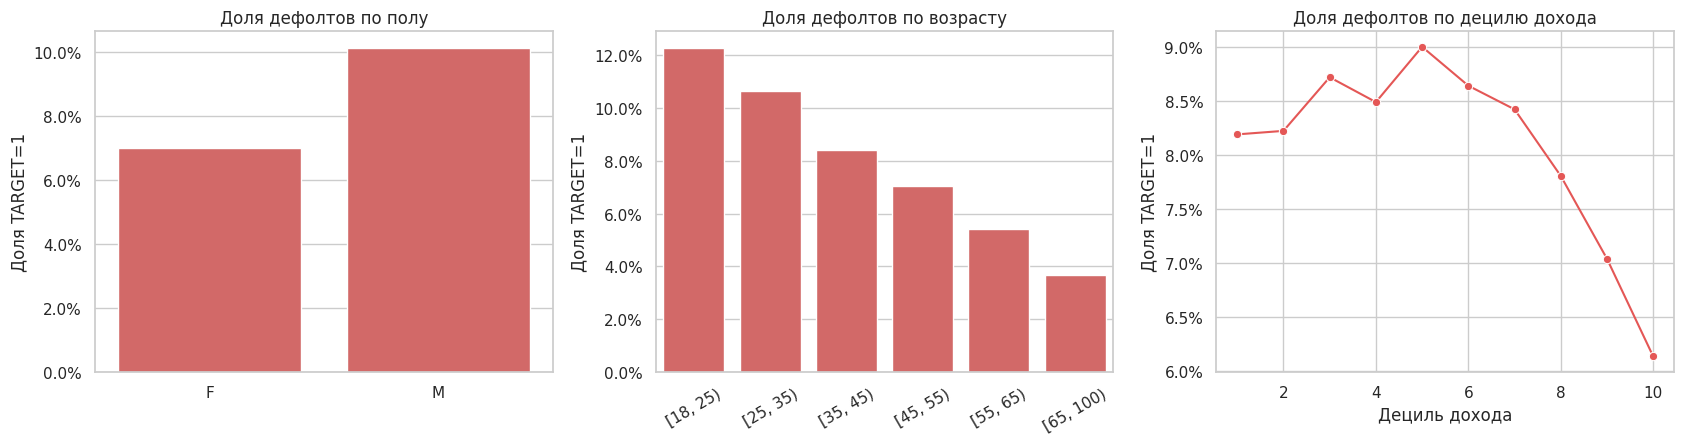


Пол


,mean,size
CODE_GENDER,,
F,7.00%,202448
M,10.14%,105059



Возраст


,mean,size
age_group,,
"[18, 25)",12.29%,12233
"[25, 35)",10.66%,72429
"[35, 45)",8.41%,84261
"[45, 55)",7.05%,70190
"[55, 65)",5.42%,60522
"[65, 100)",3.66%,7876



Доход


,mean,size
income_decile,,
1,8.19%,33391
2,8.22%,30280
3,8.72%,36907
4,8.49%,48849
5,9.00%,4333
6,8.64%,31120
7,8.42%,30704
8,7.81%,44809
9,7.04%,19957


Категория XNA не показана на графике пола: в ней всего 4 заявки.


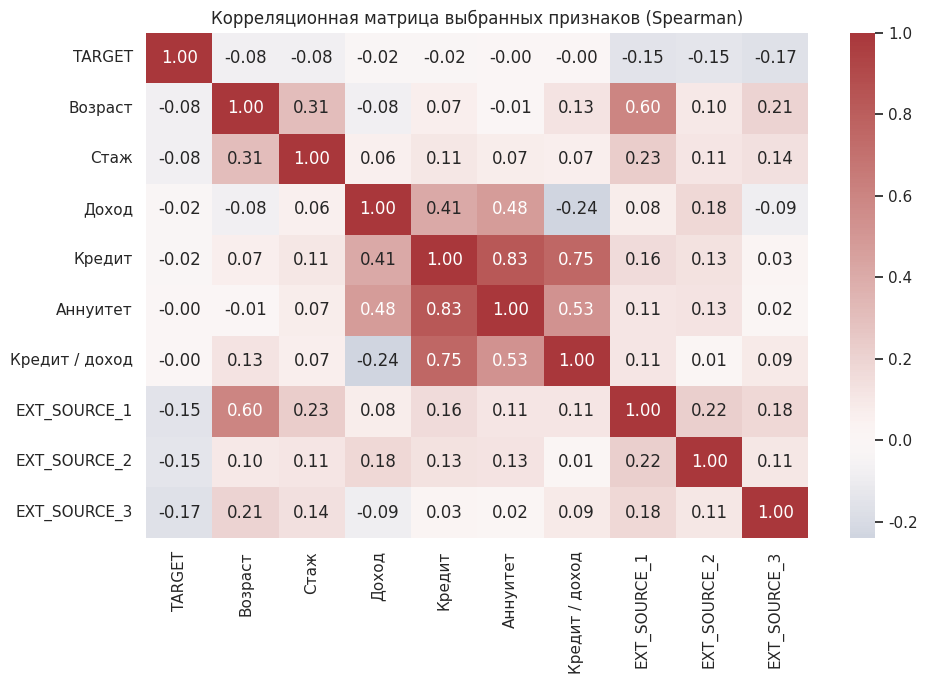

In [29]:
eda_frame = application_train.assign(
    age_years=-application_train['DAYS_BIRTH'] / 365.25,
    employment_years=np.where(
        application_train['DAYS_EMPLOYED'].eq(365243),
        np.nan,
        -application_train['DAYS_EMPLOYED'] / 365.25,
    ),
    credit_to_income=(
        application_train['AMT_CREDIT']
        / application_train['AMT_INCOME_TOTAL'].clip(lower=1)
    ),
)
eda_frame['age_group'] = pd.cut(
    eda_frame['age_years'],
    bins=[18, 25, 35, 45, 55, 65, 100],
    right=False,
)
eda_frame['income_decile'] = pd.qcut(
    eda_frame['AMT_INCOME_TOTAL'],
    q=10,
    duplicates='drop',
    labels=range(1, 11),
)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))

gender_risk = (
    eda_frame.loc[eda_frame['CODE_GENDER'].ne('XNA')]
    .groupby('CODE_GENDER', observed=False)['TARGET']
    .agg(['mean', 'size'])
    .reset_index()
)
sns.barplot(data=gender_risk, x='CODE_GENDER', y='mean', color='#E45756', ax=axes[0])
axes[0].set(title='Доля дефолтов по полу', xlabel='', ylabel='Доля TARGET=1')

age_risk = (
    eda_frame.groupby('age_group', observed=False)['TARGET']
    .agg(['mean', 'size'])
    .reset_index()
)
sns.barplot(data=age_risk, x='age_group', y='mean', color='#E45756', ax=axes[1])
axes[1].set(title='Доля дефолтов по возрасту', xlabel='', ylabel='Доля TARGET=1')
axes[1].tick_params(axis='x', rotation=30)

income_risk = (
    eda_frame.groupby('income_decile', observed=False)['TARGET']
    .agg(['mean', 'size'])
    .reset_index()
)
sns.lineplot(data=income_risk, x='income_decile', y='mean', marker='o', color='#E45756', ax=axes[2])
axes[2].set(title='Доля дефолтов по децилю дохода', xlabel='Дециль дохода', ylabel='Доля TARGET=1')

for axis in axes:
    axis.yaxis.set_major_formatter(lambda value, _: f'{value:.1%}')

fig.tight_layout()
fig.savefig(FIGURES_DIR / '03_risk_segments.png', dpi=160, bbox_inches='tight')
plt.show()

for name, table in {
    'Пол': gender_risk.set_index('CODE_GENDER'),
    'Возраст': age_risk.set_index('age_group'),
    'Доход': income_risk.set_index('income_decile'),
}.items():
    print(f'\n{name}')
    display(table.style.format({'mean': '{:.2%}'}))

print('Категория XNA не показана на графике пола: в ней всего 4 заявки.')

# Корреляции смотрю на небольшом наборе интерпретируемых признаков.
# Spearman устойчивее Pearson к длинным хвостам и нелинейной монотонной связи.
corr_frame = pd.DataFrame({
    'TARGET': eda_frame['TARGET'],
    'Возраст': eda_frame['age_years'],
    'Стаж': eda_frame['employment_years'],
    'Доход': eda_frame['AMT_INCOME_TOTAL'],
    'Кредит': eda_frame['AMT_CREDIT'],
    'Аннуитет': eda_frame['AMT_ANNUITY'],
    'Кредит / доход': eda_frame['credit_to_income'],
    'EXT_SOURCE_1': eda_frame['EXT_SOURCE_1'],
    'EXT_SOURCE_2': eda_frame['EXT_SOURCE_2'],
    'EXT_SOURCE_3': eda_frame['EXT_SOURCE_3'],
})
corr = corr_frame.corr(method='spearman')
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, cmap='vlag', center=0, annot=True, fmt='.2f', square=False, ax=ax)
ax.set_title('Корреляционная матрица выбранных признаков (Spearman)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / '03b_correlation_matrix.png', dpi=160, bbox_inches='tight')
plt.show()


### 2.4. Насколько полная кредитная история

Перед объединением таблиц проверяю, для какой доли клиентов вообще есть записи в `bureau`, прошлых заявках, POS, рассрочках и кредитных картах. Отсутствие записи считаю нормальным состоянием, а не поводом удалять клиента.

In [30]:
source_specs = {'bureau.csv': 'SK_ID_CURR', 'previous_application.csv': 'SK_ID_CURR', 'POS_CASH_balance.csv': 'SK_ID_CURR', 'installments_payments.csv': 'SK_ID_CURR', 'credit_card_balance.csv': 'SK_ID_CURR'}
train_id_set = set(application_train['SK_ID_CURR'])
test_id_set = set(application_test['SK_ID_CURR'])
all_application_ids = train_id_set | test_id_set
source_coverage_rows = []
for filename, key in source_specs.items():
    ids = pd.read_csv(DATA_DIR / filename, usecols=[key])[key]
    unique_ids = set(ids.unique())
    unknown_ids = unique_ids - all_application_ids
    source_coverage_rows.append({
        'source': filename,
        'rows': len(ids),
        'unique_clients': len(unique_ids),
        'coverage_train_clients': len(unique_ids & train_id_set) / len(train_id_set),
        'coverage_test_clients': len(unique_ids & test_id_set) / len(test_id_set),
        'unknown_client_ids': len(unknown_ids),
        'mean_rows_per_client': len(ids) / len(unique_ids),
    })
source_coverage = pd.DataFrame(source_coverage_rows)
display(source_coverage.style.format({'coverage_train_clients': '{:.2%}', 'coverage_test_clients': '{:.2%}', 'mean_rows_per_client': '{:.1f}'}).set_caption('Покрытие заявителей и ссылочная целостность вспомогательных источников'))
assert source_coverage['unknown_client_ids'].eq(0).all(), 'Во внешних таблицах найдены ID, которых нет среди заявок train/test'

,source,rows,unique_clients,coverage_train_clients,coverage_test_clients,unknown_client_ids,mean_rows_per_client
0,bureau.csv,1716428,305811,85.69%,86.82%,0,5.6
1,previous_application.csv,1670214,338857,94.65%,98.06%,0,4.9
2,POS_CASH_balance.csv,10001358,337252,94.12%,98.08%,0,29.7
3,installments_payments.csv,13605401,339587,94.84%,98.36%,0,40.1
4,credit_card_balance.csv,3840312,103558,28.26%,34.16%,0,37.1


**Что получилось.** Лучше всего покрыты прошлые заявки, POS и рассрочки — примерно 94–95% train-клиентов. `bureau` есть примерно у 86%, а кредитные карты — только у 28%. Количество строк на клиента тоже сильно различается: например, в `installments_payments` в среднем около 40 записей, а в `bureau` — около 6. Поэтому напрямую соединять эти таблицы нельзя: сначала каждую нужно агрегировать до одной строки на `SK_ID_CURR`.

## 3. Собираю признаки

Начинаю с признаков из самой анкеты, затем добавляю агрегаты по кредитной истории. Все дополнительные таблицы сначала свожу до уровня клиента, чтобы после `merge` по-прежнему оставалась одна строка на одну заявку.

### Что беру из EDA в моделирование

- `DAYS_EMPLOYED=365243` заменяю на `NaN` и сохраняю отдельный индикатор.
- Разреженные признаки не удаляю только из-за большого числа пропусков.
- Добавляю отношения кредита, дохода и аннуитета, а также несколько сводных признаков по `EXT_SOURCE_*`.
- Для денежных величин добавляю логарифмы: исходные значения оставляю, но даю линейной модели и MLP менее перекошенное представление тех же сумм.
- Пол и возраст оставляю в модели, а позже отдельно проверяю качество и частоту ошибок по этим группам. Fairness-анализ здесь описательный и сам по себе не доказывает дискриминацию.

### 3.1. Вспомогательные функции

Здесь собраны функции для чтения данных, уменьшения расхода памяти и агрегации таблиц. Они нужны в нескольких следующих шагах, поэтому удобнее определить их один раз.

In [31]:
def reduce_memory_usage(frame: pd.DataFrame) -> pd.DataFrame:
    """Снижает расход памяти для числовых признаков; исходные CSV не изменяет."""
    for column in frame.columns:
        dtype = frame[column].dtype
        if pd.api.types.is_integer_dtype(dtype):
            frame[column] = pd.to_numeric(frame[column], downcast='integer')
        elif pd.api.types.is_float_dtype(dtype):
            frame[column] = pd.to_numeric(frame[column], downcast='float')
    return frame


def read_source(filename: str) -> pd.DataFrame:
    """Читает один источник. FAST_MODE ограничивает строки для тяжёлых таблиц."""
    nrows = FAST_NROWS if FAST_MODE and filename not in {'application_train.csv', 'application_test.csv'} else None
    frame = pd.read_csv(DATA_DIR / filename, nrows=nrows)
    return reduce_memory_usage(frame)


def flatten_aggregation(columns, prefix: str) -> list[str]:
    return [f'{prefix}__{feature}__{stat}'.upper() for feature, stat in columns]


def aggregate_numeric(frame: pd.DataFrame, key: str, prefix: str, stats=('mean', 'max', 'min', 'sum', 'var')) -> pd.DataFrame:
    """Сводит таблицу к одному наблюдению на ключ и явно сохраняет число исходных строк."""
    excluded = {key, 'SK_ID_BUREAU', 'SK_ID_PREV', 'SK_ID_CURR'}
    numeric = [column for column in frame.select_dtypes(include=np.number).columns if column not in excluded]
    grouped = frame.groupby(key, observed=True)
    counts = grouped.size().rename(f'{prefix}__ROW_COUNT'.upper())
    if not numeric:
        return counts.reset_index()
    result = grouped[numeric].agg(stats)
    result.columns = flatten_aggregation(result.columns, prefix)
    return result.join(counts).reset_index()


def aggregate_categories(frame: pd.DataFrame, key: str, prefix: str, max_levels: int = 40) -> pd.DataFrame:
    categorical = [
        column for column in frame.select_dtypes(include=['object', 'category']).columns
        if frame[column].nunique(dropna=False) <= max_levels
    ]
    if not categorical:
        return frame[[key]].drop_duplicates().copy()
    dummies = pd.get_dummies(frame[categorical].fillna('__MISSING__'), prefix=categorical, dtype='float32')
    dummies[key] = frame[key].to_numpy()
    result = dummies.groupby(key, observed=True).mean()
    result.columns = [f'{prefix}__{column}__MEAN'.upper() for column in result.columns]
    return result.reset_index()


def merge_at_application_grain(base: pd.DataFrame, features: pd.DataFrame, source_name: str) -> pd.DataFrame:
    before = len(base)
    # После downcast ключи из разных CSV могут иметь разные integer-типы.
    # Нормализуем их до merge, чтобы избежать platform-specific ошибок pandas.
    base = base.copy()
    features = features.copy()
    base['SK_ID_CURR'] = pd.Series(base['SK_ID_CURR'].to_numpy(dtype='int64'), index=base.index)
    features['SK_ID_CURR'] = pd.Series(features['SK_ID_CURR'].to_numpy(dtype='int64'), index=features.index)
    merged = base.merge(features, on='SK_ID_CURR', how='left', validate='one_to_one')
    assert len(merged) == before, f'{source_name}: нарушена гранулярность строк'
    return merged


def safe_ratio(numerator: pd.Series, denominator: pd.Series) -> pd.Series:
    value = numerator.astype('float32') / denominator.astype('float32').replace(0, np.nan)
    return value.replace([np.inf, -np.inf], np.nan)


def aggregate_selected_numeric(frame: pd.DataFrame, key: str, prefix: str, columns: list[str], stats=('mean', 'max', 'sum')) -> pd.DataFrame:
    """Компактная агрегация выбранных числовых полей для временных срезов истории."""
    available = [column for column in columns if column in frame.columns]
    grouped = frame.groupby(key, observed=True)
    counts = grouped.size().rename(f'{prefix}__ROW_COUNT'.upper())
    if not available:
        return counts.reset_index()
    result = grouped[available].agg(stats)
    result.columns = flatten_aggregation(result.columns, prefix)
    return result.join(counts).reset_index()

In [32]:
def enrich_application(frame: pd.DataFrame) -> pd.DataFrame:
    """Строит только признаки из анкеты на момент подачи заявки."""
    result = frame.copy()
    result['APP__EMPLOYMENT_ANOMALY'] = result['DAYS_EMPLOYED'].eq(365243).astype('int8')
    result['DAYS_EMPLOYED'] = result['DAYS_EMPLOYED'].replace(365243, np.nan)
    result['APP__AGE_YEARS'] = -result['DAYS_BIRTH'] / 365.25
    result['APP__EMPLOYMENT_YEARS'] = -result['DAYS_EMPLOYED'] / 365.25
    result['APP__REGISTRATION_YEARS'] = -result['DAYS_REGISTRATION'] / 365.25
    result['APP__ID_PUBLISH_YEARS'] = -result['DAYS_ID_PUBLISH'] / 365.25
    result['APP__PHONE_CHANGE_YEARS'] = -result['DAYS_LAST_PHONE_CHANGE'] / 365.25
    result['APP__AGE_AT_EMPLOYMENT_START'] = result['APP__AGE_YEARS'] - result['APP__EMPLOYMENT_YEARS']

    result['APP__CREDIT_TO_INCOME'] = safe_ratio(result['AMT_CREDIT'], result['AMT_INCOME_TOTAL'])
    result['APP__ANNUITY_TO_INCOME'] = safe_ratio(result['AMT_ANNUITY'], result['AMT_INCOME_TOTAL'])
    result['APP__CREDIT_TO_ANNUITY'] = safe_ratio(result['AMT_CREDIT'], result['AMT_ANNUITY'])
    result['APP__PAYMENT_RATE'] = safe_ratio(result['AMT_ANNUITY'], result['AMT_CREDIT'])
    result['APP__GOODS_TO_CREDIT'] = safe_ratio(result['AMT_GOODS_PRICE'], result['AMT_CREDIT'])
    result['APP__CREDIT_PER_PERSON'] = safe_ratio(result['AMT_CREDIT'], result['CNT_FAM_MEMBERS'])
    result['APP__INCOME_PER_PERSON'] = safe_ratio(result['AMT_INCOME_TOTAL'], result['CNT_FAM_MEMBERS'])
    result['APP__INCOME_PER_CHILD'] = safe_ratio(result['AMT_INCOME_TOTAL'], result['CNT_CHILDREN'] + 1)
    result['APP__CHILD_TO_FAMILY'] = safe_ratio(result['CNT_CHILDREN'], result['CNT_FAM_MEMBERS'])
    result['APP__EMPLOYED_TO_AGE'] = safe_ratio(result['APP__EMPLOYMENT_YEARS'], result['APP__AGE_YEARS'])

    ext_sources = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
    result['APP__EXT_SOURCE_MEAN'] = result[ext_sources].mean(axis=1)
    result['APP__EXT_SOURCE_STD'] = result[ext_sources].std(axis=1)
    result['APP__EXT_SOURCE_MIN'] = result[ext_sources].min(axis=1)
    result['APP__EXT_SOURCE_MAX'] = result[ext_sources].max(axis=1)
    result['APP__EXT_SOURCE_RANGE'] = result['APP__EXT_SOURCE_MAX'] - result['APP__EXT_SOURCE_MIN']
    result['APP__EXT_SOURCE_AVAILABLE'] = result[ext_sources].notna().sum(axis=1).astype('int8')
    result['APP__CONTACT_FLAGS_SUM'] = result[['FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL']].sum(axis=1)
    result['APP__DOCUMENT_FLAGS_SUM'] = result[[column for column in result if column.startswith('FLAG_DOCUMENT_')]].sum(axis=1)
    result['APP__REGION_MISMATCH_SUM'] = result[[column for column in result if '_REGION_NOT_' in column or '_CITY_NOT_' in column]].sum(axis=1)
    result['APP__BUREAU_REQUESTS_SUM'] = result[[column for column in result if column.startswith('AMT_REQ_CREDIT_BUREAU_')]].sum(axis=1)

    monetary = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']
    for column in monetary:
        result[f'APP__LOG1P__{column}'] = np.log1p(result[column].clip(lower=0))
        result[f'APP__{column}__MISSING'] = result[column].isna().astype('int8')
    return reduce_memory_usage(result)

### 3.2. Признаки из кредитной истории

Для каждой дополнительной таблицы считаю агрегаты по клиенту: количество записей, средние и экстремальные значения, доли категорий, просрочки и несколько временных срезов.

Отдельно хочу проверить, дают ли пользу: текущая кредитная нагрузка, активные кредиты, прошлые отказы, частота просрочек и недавние события. `bureau_balance` сначала свожу до `SK_ID_BUREAU`, а уже потом до `SK_ID_CURR`.

In [33]:
def bureau_features() -> pd.DataFrame:
    bureau = read_source('bureau.csv')
    balance = read_source('bureau_balance.csv')
    balance_numeric = aggregate_numeric(balance, 'SK_ID_BUREAU', 'BUREAU_BALANCE', stats=('mean', 'max', 'min', 'sum', 'var'))
    balance_categories = aggregate_categories(balance, 'SK_ID_BUREAU', 'BUREAU_BALANCE')
    balance_level = balance_numeric.merge(balance_categories, on='SK_ID_BUREAU', how='left', validate='one_to_one')
    bureau['SK_ID_BUREAU'] = bureau['SK_ID_BUREAU'].astype('int64')
    balance_level['SK_ID_BUREAU'] = balance_level['SK_ID_BUREAU'].astype('int64')
    bureau = bureau.merge(balance_level, on='SK_ID_BUREAU', how='left', validate='one_to_one')
    del balance, balance_numeric, balance_categories, balance_level
    gc.collect()

    bureau['BUREAU__DEBT_TO_CREDIT'] = safe_ratio(bureau['AMT_CREDIT_SUM_DEBT'], bureau['AMT_CREDIT_SUM'])
    bureau['BUREAU__OVERDUE_TO_CREDIT'] = safe_ratio(bureau['AMT_CREDIT_SUM_OVERDUE'], bureau['AMT_CREDIT_SUM'])
    bureau['BUREAU__OVERDUE_TO_DEBT'] = safe_ratio(bureau['AMT_CREDIT_SUM_OVERDUE'], bureau['AMT_CREDIT_SUM_DEBT'])
    bureau['BUREAU__LIMIT_TO_CREDIT'] = safe_ratio(bureau['AMT_CREDIT_SUM_LIMIT'], bureau['AMT_CREDIT_SUM'])
    bureau['BUREAU__HAS_OVERDUE'] = bureau['AMT_CREDIT_SUM_OVERDUE'].gt(0).astype('int8')
    bureau['BUREAU__PROLONGED_FLAG'] = bureau['CNT_CREDIT_PROLONG'].gt(0).astype('int8')
    bureau['BUREAU__ENDDATE_GAP'] = bureau['DAYS_ENDDATE_FACT'] - bureau['DAYS_CREDIT_ENDDATE']

    numeric = aggregate_numeric(bureau, 'SK_ID_CURR', 'BUREAU')
    categories = aggregate_categories(bureau, 'SK_ID_CURR', 'BUREAU')
    result = numeric.merge(categories, on='SK_ID_CURR', how='left', validate='one_to_one')
    for status, suffix in [('Active', 'ACTIVE'), ('Closed', 'CLOSED')]:
        subset = bureau.loc[bureau['CREDIT_ACTIVE'].eq(status)]
        if not subset.empty:
            subset_features = aggregate_numeric(subset, 'SK_ID_CURR', f'BUREAU_{suffix}')
            result = result.merge(subset_features, on='SK_ID_CURR', how='left', validate='one_to_one')
    for days, suffix in [(365, 'RECENT_365D'), (730, 'RECENT_730D')]:
        recent = bureau.loc[bureau['DAYS_CREDIT'].ge(-days)]
        if not recent.empty:
            recent_features = aggregate_selected_numeric(
                recent, 'SK_ID_CURR', f'BUREAU_{suffix}',
                ['AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_OVERDUE', 'BUREAU__HAS_OVERDUE'],
            )
            result = result.merge(recent_features, on='SK_ID_CURR', how='left', validate='one_to_one')
    del bureau, numeric, categories
    gc.collect()
    return reduce_memory_usage(result)


def previous_application_features() -> pd.DataFrame:
    previous = read_source('previous_application.csv')
    day_columns = ['DAYS_FIRST_DRAWING', 'DAYS_FIRST_DUE', 'DAYS_LAST_DUE_1ST_VERSION', 'DAYS_LAST_DUE', 'DAYS_TERMINATION']
    previous[day_columns] = previous[day_columns].replace(365243, np.nan)
    previous['PREV__APPLICATION_TO_CREDIT'] = safe_ratio(previous['AMT_APPLICATION'], previous['AMT_CREDIT'])
    previous['PREV__DOWN_PAYMENT_TO_CREDIT'] = safe_ratio(previous['AMT_DOWN_PAYMENT'], previous['AMT_CREDIT'])
    previous['PREV__CREDIT_TO_GOODS'] = safe_ratio(previous['AMT_CREDIT'], previous['AMT_GOODS_PRICE'])
    previous['PREV__APPLICATION_GAP'] = previous['AMT_APPLICATION'] - previous['AMT_CREDIT']
    previous['PREV__HAS_DOWN_PAYMENT'] = previous['AMT_DOWN_PAYMENT'].gt(0).astype('int8')
    numeric = aggregate_numeric(previous, 'SK_ID_CURR', 'PREVIOUS')
    categories = aggregate_categories(previous, 'SK_ID_CURR', 'PREVIOUS')
    result = numeric.merge(categories, on='SK_ID_CURR', how='left', validate='one_to_one')
    for status, suffix in [('Approved', 'APPROVED'), ('Refused', 'REFUSED')]:
        subset = previous.loc[previous['NAME_CONTRACT_STATUS'].eq(status)]
        if not subset.empty:
            subset_features = aggregate_numeric(subset, 'SK_ID_CURR', f'PREVIOUS_{suffix}')
            result = result.merge(subset_features, on='SK_ID_CURR', how='left', validate='one_to_one')
    recent = previous.loc[previous['DAYS_DECISION'].ge(-365)]
    if not recent.empty:
        recent_features = aggregate_selected_numeric(
            recent, 'SK_ID_CURR', 'PREVIOUS_RECENT_365D',
            ['AMT_APPLICATION', 'AMT_CREDIT', 'AMT_ANNUITY', 'PREV__APPLICATION_GAP'],
        )
        result = result.merge(recent_features, on='SK_ID_CURR', how='left', validate='one_to_one')
    del previous, numeric, categories
    gc.collect()
    return reduce_memory_usage(result)


def pos_cash_features() -> pd.DataFrame:
    pos = read_source('POS_CASH_balance.csv')
    pos['POS__LATE_PAYMENT_FLAG'] = pos['SK_DPD'].gt(0).astype('int8')
    pos['POS__SEVERE_LATE_FLAG'] = pos['SK_DPD_DEF'].gt(0).astype('int8')
    pos['POS__MONTHS_REMAINING_RATIO'] = safe_ratio(pos['CNT_INSTALMENT_FUTURE'], pos['CNT_INSTALMENT'])
    numeric = aggregate_numeric(pos, 'SK_ID_CURR', 'POS')
    categories = aggregate_categories(pos, 'SK_ID_CURR', 'POS')
    result = numeric.merge(categories, on='SK_ID_CURR', how='left', validate='one_to_one')
    recent = pos.loc[pos['MONTHS_BALANCE'].ge(-6)]
    if not recent.empty:
        recent_features = aggregate_selected_numeric(
            recent, 'SK_ID_CURR', 'POS_RECENT_6M',
            ['SK_DPD', 'SK_DPD_DEF', 'CNT_INSTALMENT_FUTURE', 'POS__LATE_PAYMENT_FLAG'],
        )
        result = result.merge(recent_features, on='SK_ID_CURR', how='left', validate='one_to_one')
    del pos, numeric, categories
    gc.collect()
    return reduce_memory_usage(result)


def installments_features() -> pd.DataFrame:
    installments = read_source('installments_payments.csv')
    installments['INST__PAYMENT_DIFF'] = installments['AMT_INSTALMENT'] - installments['AMT_PAYMENT']
    installments['INST__PAYMENT_RATIO'] = safe_ratio(installments['AMT_PAYMENT'], installments['AMT_INSTALMENT'])
    installments['INST__DAYS_LATE'] = (installments['DAYS_ENTRY_PAYMENT'] - installments['DAYS_INSTALMENT']).clip(lower=0)
    installments['INST__DAYS_EARLY'] = (installments['DAYS_INSTALMENT'] - installments['DAYS_ENTRY_PAYMENT']).clip(lower=0)
    installments['INST__LATE_FLAG'] = installments['INST__DAYS_LATE'].gt(0).astype('int8')
    installments['INST__UNDERPAID_FLAG'] = installments['INST__PAYMENT_DIFF'].gt(0).astype('int8')
    numeric = aggregate_numeric(installments, 'SK_ID_CURR', 'INSTALLMENTS')
    result = numeric
    recent = installments.loc[installments['DAYS_INSTALMENT'].ge(-365)]
    if not recent.empty:
        recent_features = aggregate_selected_numeric(
            recent, 'SK_ID_CURR', 'INSTALLMENTS_RECENT_365D',
            ['INST__PAYMENT_DIFF', 'INST__PAYMENT_RATIO', 'INST__DAYS_LATE', 'INST__LATE_FLAG', 'INST__UNDERPAID_FLAG'],
        )
        result = result.merge(recent_features, on='SK_ID_CURR', how='left', validate='one_to_one')
    del installments, numeric
    gc.collect()
    return reduce_memory_usage(result)


def credit_card_features() -> pd.DataFrame:
    card = read_source('credit_card_balance.csv')
    card['CC__UTILIZATION'] = safe_ratio(card['AMT_BALANCE'], card['AMT_CREDIT_LIMIT_ACTUAL'])
    card['CC__DRAWING_TO_LIMIT'] = safe_ratio(card['AMT_DRAWINGS_CURRENT'], card['AMT_CREDIT_LIMIT_ACTUAL'])
    card['CC__PAYMENT_TO_BALANCE'] = safe_ratio(card['AMT_PAYMENT_CURRENT'], card['AMT_BALANCE'])
    card['CC__MIN_PAYMENT_TO_BALANCE'] = safe_ratio(card['AMT_INST_MIN_REGULARITY'], card['AMT_BALANCE'])
    card['CC__LATE_FLAG'] = card['SK_DPD'].gt(0).astype('int8')
    card['CC__OVER_LIMIT_FLAG'] = card['AMT_BALANCE'].gt(card['AMT_CREDIT_LIMIT_ACTUAL']).astype('int8')
    numeric = aggregate_numeric(card, 'SK_ID_CURR', 'CREDIT_CARD')
    result = numeric
    recent = card.loc[card['MONTHS_BALANCE'].ge(-6)]
    if not recent.empty:
        recent_features = aggregate_selected_numeric(
            recent, 'SK_ID_CURR', 'CREDIT_CARD_RECENT_6M',
            ['AMT_BALANCE', 'AMT_DRAWINGS_CURRENT', 'CC__UTILIZATION', 'CC__LATE_FLAG', 'CC__OVER_LIMIT_FLAG'],
        )
        result = result.merge(recent_features, on='SK_ID_CURR', how='left', validate='one_to_one')
    del card, numeric
    gc.collect()
    return reduce_memory_usage(result)

In [34]:
def build_model_matrix() -> tuple[pd.DataFrame, pd.Series, pd.DataFrame, list[str]]:
    """Собирает матрицы без fit на TARGET и без использования test при кодировании train."""
    train = read_source('application_train.csv')
    test = read_source('application_test.csv')
    target = train.pop('TARGET').astype('int8')
    train['__IS_TRAIN'] = 1
    test['__IS_TRAIN'] = 0
    # Совместная инженерия допустима: ни одна операция ниже не использует label.
    # Кодирование категорий и отбор признаков далее выполняются только по train.
    base = enrich_application(pd.concat([train, test], axis=0, ignore_index=True, sort=False))
    del train, test
    gc.collect()

    feature_builders = {
        'bureau': bureau_features,
        'previous_application': previous_application_features,
        'pos_cash': pos_cash_features,
        'installments': installments_features,
        'credit_card': credit_card_features,
    }
    feature_audit = []
    for name, builder in feature_builders.items():
        started = perf_counter()
        source_features = builder()
        feature_audit.append({'source': name, 'rows': len(source_features), 'new_features': source_features.shape[1] - 1, 'seconds': perf_counter() - started})
        base = merge_at_application_grain(base, source_features, name)
        del source_features
        gc.collect()

    base = base.replace([np.inf, -np.inf], np.nan)
    train_base = base.loc[base['__IS_TRAIN'].eq(1)].drop(columns='__IS_TRAIN').copy()
    test_base = base.loc[base['__IS_TRAIN'].eq(0)].drop(columns='__IS_TRAIN').copy()
    del base
    gc.collect()

    categorical = train_base.select_dtypes(include=['object', 'category']).columns.tolist()
    for column in categorical:
        # Категории и их коды задаёт только train; неизвестные значения test получают -1.
        train_values = train_base[column].fillna('__MISSING__').astype(str)
        test_values = test_base[column].fillna('__MISSING__').astype(str)
        codebook = {value: code for code, value in enumerate(pd.unique(train_values))}
        train_base[column] = train_values.map(codebook).astype('int32')
        test_base[column] = test_values.map(codebook).fillna(-1).astype('int32')

    constant_columns = [column for column in train_base.columns if column != 'SK_ID_CURR' and train_base[column].nunique(dropna=False) <= 1]
    train_matrix = train_base.drop(columns=constant_columns).reset_index(drop=True)
    test_matrix = test_base.drop(columns=constant_columns).reset_index(drop=True)
    categorical = [column for column in categorical if column in train_matrix.columns]
    assert len(train_matrix) == len(target)
    assert train_matrix.columns.tolist() == test_matrix.columns.tolist()
    assert train_matrix['SK_ID_CURR'].is_unique and test_matrix['SK_ID_CURR'].is_unique
    assert set(train_matrix['SK_ID_CURR']).isdisjoint(set(test_matrix['SK_ID_CURR']))
    audit = pd.DataFrame(feature_audit)
    global feature_build_audit
    feature_build_audit = audit.copy()
    display(audit.style.format({'seconds': '{:.1f}'}).set_caption('Аудит построения признаков: число новых признаков по источнику'))
    print(f'Итог матриц: train={train_matrix.shape}, test={test_matrix.shape}; удалено константных признаков: {len(constant_columns)}')
    return train_matrix, target.reset_index(drop=True), test_matrix, categorical

**Проверка после сборки признаков.** `TARGET` в feature engineering не используется. После каждого объединения проверяю, что число заявок не изменилось и `SK_ID_CURR` остался уникальным. Это простая защита от случайного размножения строк.

Перед полным обучением отдельно проверяю функции агрегации на реальных файлах и печатаю итоговую размерность матрицы. Это помогает заметить ошибку раньше, чем начнётся долгий запуск моделей.

## 4. Первые модели: только данные текущей заявки

Сначала делаю baseline без дополнительных таблиц кредитной и платёжной истории. Так можно понять, сколько качества уже содержится в самой заявке и внешних признаках из `application_train`.

Для сравнения использую одни и те же 5 фолдов. Основная метрика — ROC-AUC, дополнительно сохраняю PR-AUC, Brier score и время обучения.

In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, average_precision_score, brier_score_loss, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from lightgbm.basic import LightGBMError
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)


def check_lightgbm_cuda() -> None:
    # Проверяет CUDA-сборку до запуска долгого обучения.
    sample_features = pd.DataFrame({'feature': np.arange(32, dtype='float32')})
    sample_target = np.tile([0, 1], 16)
    try:
        LGBMClassifier(
            n_estimators=1,
            min_child_samples=1,
            random_state=RANDOM_STATE,
            verbosity=-1,
            **LGBM_DEVICE_PARAMS,
        ).fit(sample_features, sample_target)
    except LightGBMError as error:
        raise RuntimeError(
            'LightGBM установлен без CUDA. В терминале kernel-окружения выполните: '
            'conda install -c conda-forge lightgbm, затем перезапустите kernel.'
        ) from error


check_lightgbm_cuda()
print('LightGBM CUDA-проверка пройдена.')


def make_folds(target: pd.Series):
    splitter = StratifiedKFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE,
    )
    return list(splitter.split(np.zeros(len(target)), target))


def split_outer_train_for_early_stopping(
    outer_train_idx: np.ndarray,
    target: pd.Series,
    fold: int,
    validation_size: float = 0.15,
) -> tuple[np.ndarray, np.ndarray]:
    splitter = StratifiedShuffleSplit(
        n_splits=1,
        test_size=validation_size,
        random_state=RANDOM_STATE + fold,
    )
    fit_positions, stop_positions = next(
        splitter.split(
            np.zeros(len(outer_train_idx)),
            target.iloc[outer_train_idx],
        )
    )
    return outer_train_idx[fit_positions], outer_train_idx[stop_positions]


def score_predictions(y_true: np.ndarray, probabilities: np.ndarray) -> dict:
    predicted_at_05 = (np.asarray(probabilities) >= 0.5).astype('int8')
    return {
        'roc_auc': roc_auc_score(y_true, probabilities),
        'pr_auc': average_precision_score(y_true, probabilities),
        'brier': brier_score_loss(y_true, probabilities),
        'accuracy_05': accuracy_score(y_true, predicted_at_05),
        'f1_05': f1_score(y_true, predicted_at_05, zero_division=0),
    }


def operating_threshold_from_oof(y_true: np.ndarray, probabilities: np.ndarray) -> float:
    from sklearn.metrics import precision_recall_curve

    precision, recall, thresholds = precision_recall_curve(y_true, probabilities)
    f1 = 2 * precision * recall / np.clip(precision + recall, 1e-12, None)
    return float(thresholds[int(np.nanargmax(f1[:-1]))])


def cv_predict(estimator_factory, X: pd.DataFrame, y: pd.Series, model_name: str, fit_kwargs_factory=None):
    folds = make_folds(y)
    oof = np.zeros(len(X), dtype='float32')
    fold_rows = []
    fitted_models = []
    for fold, (train_idx, valid_idx) in enumerate(folds, start=1):
        model = estimator_factory()
        started = perf_counter()
        fit_kwargs = {} if fit_kwargs_factory is None else fit_kwargs_factory(
            X.iloc[train_idx], y.iloc[train_idx], X.iloc[valid_idx], y.iloc[valid_idx]
        )
        model.fit(X.iloc[train_idx], y.iloc[train_idx], **fit_kwargs)
        valid_pred = model.predict_proba(X.iloc[valid_idx])[:, 1]
        oof[valid_idx] = valid_pred
        fold_score = score_predictions(y.iloc[valid_idx].to_numpy(), valid_pred)
        fold_rows.append({'model': model_name, 'fold': fold, 'seconds': perf_counter() - started, **fold_score})
        fitted_models.append(model)
        print(f'{model_name}, fold {fold}: ROC-AUC={fold_score["roc_auc"]:.5f}, PR-AUC={fold_score["pr_auc"]:.5f}')
    total = score_predictions(y.to_numpy(), oof)
    print(f'Итого {model_name}: ROC-AUC={total["roc_auc"]:.5f}, PR-AUC={total["pr_auc"]:.5f}')
    return oof, fitted_models, pd.DataFrame(fold_rows), total

LightGBM CUDA-проверка пройдена.


### 4.1. Логистическая регрессия и одно дерево

Начинаю с двух простых моделей. Логистическая регрессия даёт линейную точку отсчёта, а одно дерево показывает, сколько можно выиграть за счёт нелинейных разбиений без ансамбля.

In [36]:
# Сначала строим матрицу только по анкете: она одинакова для всех baseline-моделей.
def application_only_features(raw: pd.DataFrame) -> pd.DataFrame:
    """Признаки только из основной таблицы заявки, без исторических источников."""
    frame = raw.drop(columns=['TARGET'], errors='ignore').copy()
    frame = enrich_application(frame)
    return frame.drop(columns='SK_ID_CURR').replace([np.inf, -np.inf], np.nan)


X_application = application_only_features(application_train)
y_application = application_train['TARGET'].astype('int8')

# Воспроизводимое сравнение линейной модели и одиночного дерева на той же анкете.
# Все импутеры, масштабирование и one-hot encoding fit внутри каждого CV-train фолда.
numeric_application = X_application.select_dtypes(include=np.number).columns.tolist()
categorical_application = [column for column in X_application.columns if column not in numeric_application]

classic_models = {
    'Логистическая регрессия': Pipeline([
        ('prep', ColumnTransformer([
            ('numeric', Pipeline([('imputer', SimpleImputer(strategy='median', add_indicator=True)), ('scaler', StandardScaler())]), numeric_application),
            ('categorical', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore'))]), categorical_application),
        ])),
        ('model', LogisticRegression(C=0.1, max_iter=300, tol=1e-3, class_weight='balanced', solver='saga', n_jobs=-1, random_state=RANDOM_STATE)),
    ]),
    'Одиночное дерево': Pipeline([
        ('prep', ColumnTransformer([
            ('numeric', SimpleImputer(strategy='median', add_indicator=True), numeric_application),
            ('categorical', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore'))]), categorical_application),
        ])),
        ('model', DecisionTreeClassifier(max_depth=6, min_samples_leaf=500, class_weight='balanced', random_state=RANDOM_STATE)),
    ]),
}
classic_rows = []
classic_oof_predictions = {}
classic_metrics = {}
for name, estimator in classic_models.items():
    oof = np.zeros(len(X_application), dtype='float32')
    for fold, (train_idx, valid_idx) in enumerate(make_folds(y_application), start=1):
        started = perf_counter()
        estimator.fit(X_application.iloc[train_idx], y_application.iloc[train_idx])
        oof[valid_idx] = estimator.predict_proba(X_application.iloc[valid_idx])[:, 1]
        classic_rows.append({'model': name, 'fold': fold, 'seconds': perf_counter() - started, **score_predictions(y_application.iloc[valid_idx], oof[valid_idx])})
    classic_oof_predictions[name] = oof
    classic_metrics[name] = score_predictions(y_application, oof)
    print(f'{name}: OOF ROC-AUC={roc_auc_score(y_application, oof):.5f}; PR-AUC={average_precision_score(y_application, oof):.5f}')
application_classic_baseline_results = pd.DataFrame(classic_rows)
display(application_classic_baseline_results.style.format({'roc_auc': '{:.5f}', 'pr_auc': '{:.5f}', 'brier': '{:.5f}', 'seconds': '{:.1f}'}))

Логистическая регрессия: OOF ROC-AUC=0.75126; PR-AUC=0.23164
Одиночное дерево: OOF ROC-AUC=0.72776; PR-AUC=0.20338


,model,fold,seconds,roc_auc,pr_auc,brier,accuracy_05,f1_05
0,Логистическая регрессия,1,130.0,0.74905,0.23148,0.20321,0.686194,0.260593
1,Логистическая регрессия,2,125.5,0.74924,0.23183,0.20067,0.688986,0.259752
2,Логистическая регрессия,3,117.1,0.74841,0.22899,0.20225,0.688742,0.260688
3,Логистическая регрессия,4,114.0,0.75531,0.23281,0.20163,0.689847,0.265018
4,Логистическая регрессия,5,166.5,0.75434,0.23516,0.20198,0.686384,0.260032
5,Одиночное дерево,1,11.6,0.72506,0.19688,0.20961,0.670130,0.243267
6,Одиночное дерево,2,11.5,0.72566,0.20004,0.20685,0.679019,0.247991
7,Одиночное дерево,3,11.4,0.72643,0.19973,0.20835,0.710123,0.254620
8,Одиночное дерево,4,11.5,0.73221,0.20212,0.20801,0.672840,0.249132
9,Одиночное дерево,5,11.4,0.72894,0.19858,0.20862,0.654093,0.243726


### 4.2. LightGBM только по текущей заявке

Следующий шаг — более сильный baseline на **том же наборе анкетных признаков**, который использовался выше. Именно с ним дальше сравниваю LightGBM после добавления исторических таблиц: так прирост не смешивается с изменением feature engineering.

In [37]:
# 5-fold baseline LightGBM на тех же анкетных данных.
# Он показывает, что даёт нелинейность ещё до присоединения кредитной истории.
# Категории кодируются отдельно в каждом train-fold: validation не влияет на словарь кодов.
def fold_safe_category_codes(train_frame: pd.DataFrame, valid_frame: pd.DataFrame, columns: list[str]) -> tuple[pd.DataFrame, pd.DataFrame]:
    train_encoded, valid_encoded = train_frame.copy(), valid_frame.copy()
    for column in columns:
        train_values = train_encoded[column].fillna('__MISSING__').astype(str)
        valid_values = valid_encoded[column].fillna('__MISSING__').astype(str)
        codebook = {value: code for code, value in enumerate(pd.unique(train_values))}
        train_encoded[column] = train_values.map(codebook).astype('int32')
        valid_encoded[column] = valid_values.map(codebook).fillna(-1).astype('int32')
    return train_encoded, valid_encoded

application_oof = np.zeros(len(X_application), dtype='float32')
application_folds = []
for fold, (outer_train_idx, valid_idx) in enumerate(make_folds(y_application), start=1):
    started = perf_counter()
    train_idx, stop_idx = split_outer_train_for_early_stopping(
        outer_train_idx, y_application, fold
    )
    X_train_fold, X_stop_fold = fold_safe_category_codes(
        X_application.iloc[train_idx], X_application.iloc[stop_idx], categorical_application,
    )
    _, X_valid_fold = fold_safe_category_codes(
        X_application.iloc[train_idx], X_application.iloc[valid_idx], categorical_application,
    )
    model = LGBMClassifier(
        n_estimators=5_000, learning_rate=0.03, num_leaves=31, min_child_samples=80,
        subsample=0.85, subsample_freq=1, colsample_bytree=0.80, reg_alpha=0.1, reg_lambda=2.0,
        random_state=RANDOM_STATE, n_jobs=LGBM_N_JOBS, verbosity=-1,
        **LGBM_DEVICE_PARAMS,
    )
    model.fit(
        X_train_fold, y_application.iloc[train_idx],
        eval_set=[(X_stop_fold, y_application.iloc[stop_idx])], eval_metric='auc',
        callbacks=[early_stopping(200, verbose=False), log_evaluation(period=0)],
    )
    application_oof[valid_idx] = model.predict_proba(X_valid_fold)[:, 1]
    application_folds.append({'fold': fold, 'best_iteration': model.best_iteration_, 'seconds': perf_counter() - started, **score_predictions(y_application.iloc[valid_idx], application_oof[valid_idx])})
application_only_baseline_results = pd.DataFrame(application_folds)
application_lgbm_metrics = score_predictions(y_application, application_oof)
display(application_only_baseline_results.style.format({'roc_auc': '{:.5f}', 'pr_auc': '{:.5f}', 'brier': '{:.5f}', 'seconds': '{:.1f}'}))
print('Итоговый OOF ROC-AUC:', f'{roc_auc_score(y_application, application_oof):.5f}')

,fold,best_iteration,seconds,roc_auc,pr_auc,brier,accuracy_05,f1_05
0,1,915,8.5,0.76475,0.25122,0.06745,0.919711,0.050385
1,2,704,7.1,0.76545,0.25019,0.06741,0.919515,0.043293
2,3,859,8.1,0.76763,0.25291,0.06737,0.919938,0.053441
3,4,622,6.6,0.77158,0.25575,0.06720,0.919742,0.045999
4,5,547,6.2,0.76793,0.25518,0.06718,0.919450,0.039922


Итоговый OOF ROC-AUC: 0.76741


После запуска здесь будут OOF-метрики LightGBM по пяти фолдам. Дальше сравниваю с ним LightGBM на полной матрице — это наиболее прямой способ оценить добавочную пользу подробной кредитной и платёжной истории.

## 5. Добавляю кредитную историю

Теперь собираю полную матрицу: анкетные признаки плюс агрегаты из `bureau`, прошлых заявок, POS, рассрочек и кредитных карт. Это самая тяжёлая по памяти часть ноутбука, потому что исходные таблицы сначала обрабатываются в pandas.

In [38]:
import re


def make_safe_feature_names(columns: list[str]) -> list[str]:
    # LightGBM не принимает специальные JSON-символы в названиях признаков.
    safe_names = []
    occupied = set()
    for position, column in enumerate(columns):
        base_name = re.sub(r'[^A-Za-z0-9_]+', '_', str(column)).strip('_')
        base_name = base_name or f'feature_{position}'
        safe_name = base_name
        suffix = 1
        while safe_name in occupied:
            suffix += 1
            safe_name = f'{base_name}_{suffix}'
        occupied.add(safe_name)
        safe_names.append(safe_name)
    return safe_names


train_matrix, target, test_matrix, categorical_columns = build_model_matrix()
matrix_categorical_columns = categorical_columns.copy()
feature_columns = [column for column in train_matrix.columns if column != 'SK_ID_CURR']
safe_feature_names = make_safe_feature_names(feature_columns)
feature_name_map = dict(zip(feature_columns, safe_feature_names))

X = train_matrix[feature_columns].rename(columns=feature_name_map)
X_test = test_matrix[feature_columns].rename(columns=feature_name_map)
categorical_columns = [
    feature_name_map[column]
    for column in matrix_categorical_columns
    if column in feature_name_map
]

missing_feature_rate = X.isna().mean().sort_values(ascending=False).head(15).rename('missing_rate').to_frame()
display(missing_feature_rate.style.format({'missing_rate': '{:.1%}'}).set_caption('Пропуски в итоговой feature matrix'))
renamed_count = sum(old != new for old, new in feature_name_map.items())
print(
    f'До моделирования: {X.shape[0]:,} строк, {X.shape[1]:,} признаков; '
    f'категориальных столбцов: {len(categorical_columns)}; '
    f'безопасно переименовано признаков: {renamed_count}'
)


,source,rows,new_features,seconds
0,bureau,305811,547,16.7
1,previous_application,338857,521,11.3
2,pos_cash,337252,63,6.7
3,installments,339587,77,9.0
4,credit_card,103558,147,5.5


Итог матриц: train=(307511, 1477), test=(48744, 1477); удалено константных признаков: 34


,missing_rate
BUREAU_ACTIVE__BUREAU__ENDDATE_GAP__VAR,100.0%
BUREAU_ACTIVE__DAYS_ENDDATE_FACT__VAR,100.0%
PREVIOUS_APPROVED__DAYS_FIRST_DRAWING__VAR,100.0%
PREVIOUS__DAYS_FIRST_DRAWING__VAR,100.0%
PREVIOUS__RATE_INTEREST_PRIVILEGED__VAR,99.9%
PREVIOUS__RATE_INTEREST_PRIMARY__VAR,99.9%
PREVIOUS_APPROVED__RATE_INTEREST_PRIMARY__VAR,99.9%
PREVIOUS_APPROVED__RATE_INTEREST_PRIVILEGED__VAR,99.9%
BUREAU_CLOSED__BUREAU__OVERDUE_TO_DEBT__VAR,99.7%
BUREAU_ACTIVE__BUREAU__ENDDATE_GAP__MIN,99.5%


До моделирования: 307,511 строк, 1,476 признаков; категориальных столбцов: 16; безопасно переименовано признаков: 85


### 5.1. Проверка на утечки

Перед обучением проверяю базовые инварианты: `TARGET` не должен попасть в `X`, train и test должны иметь одинаковые колонки, ID должны быть уникальны и не пересекаться, а в числовых признаках не должно остаться бесконечностей.

Категориальные значения полной матрицы переводятся в целочисленные коды по словарю train без использования `TARGET`. Импутация и масштабирование для MLP и простых моделей выполняются внутри train-части каждого фолда. Early stopping использует отдельный внутренний holdout, а внешний validation-фолд остаётся для OOF-оценки.

In [39]:
def leakage_audit(
    train_matrix: pd.DataFrame,
    test_matrix: pd.DataFrame,
    target: pd.Series,
    categorical_columns: list[str],
) -> pd.DataFrame:
    """Проверяет основные runtime-инварианты перед обучением моделей."""
    feature_columns = [
        column for column in train_matrix.columns
        if column != 'SK_ID_CURR'
    ]
    numeric_columns = (
        train_matrix[feature_columns]
        .select_dtypes(include=np.number)
        .columns
        .tolist()
    )
    has_infinity = any(
        np.isinf(train_matrix[column].to_numpy(copy=False)).any()
        for column in numeric_columns
    )

    checks = {
        'TARGET отсутствует в признаках': 'TARGET' not in feature_columns,
        'train/test имеют одинаковые столбцы и порядок': (
            train_matrix.columns.tolist() == test_matrix.columns.tolist()
        ),
        'ID уникальны в train': train_matrix['SK_ID_CURR'].is_unique,
        'ID уникальны в test': test_matrix['SK_ID_CURR'].is_unique,
        'ID train и test не пересекаются': set(
            train_matrix['SK_ID_CURR']
        ).isdisjoint(set(test_matrix['SK_ID_CURR'])),
        'длина target совпадает с train': len(target) == len(train_matrix),
        'target бинарный': set(target.unique()).issubset({0, 1}),
        'категориальные столбцы есть в матрице': set(
            categorical_columns
        ).issubset(set(feature_columns)),
        'нет бесконечностей в числовых признаках': not has_infinity,
    }
    result = pd.DataFrame({
        'проверка': list(checks),
        'пройдена': list(checks.values()),
    })
    assert result['пройдена'].all(), result.loc[~result['пройдена']]
    return result


leakage_checks = leakage_audit(
    train_matrix,
    test_matrix,
    target,
    matrix_categorical_columns,
)
display(
    leakage_checks.style.applymap(
        lambda value: 'background-color: #d9ead3' if value is True else '',
        subset=['пройдена'],
    )
)
print('Базовые проверки на утечки и целостность пройдены.')


,проверка,пройдена
0,TARGET отсутствует в признаках,True
1,train/test имеют одинаковые столбцы и порядок,True
2,ID уникальны в train,True
3,ID уникальны в test,True
4,ID train и test не пересекаются,True
5,длина target совпадает с train,True
6,target бинарный,True
7,категориальные столбцы есть в матрице,True
8,нет бесконечностей в числовых признаках,True


Базовые проверки на утечки и целостность пройдены.


In [40]:
def tune_lightgbm(X_input: pd.DataFrame, y: pd.Series, categorical_features: list[str], trials: int | None = None) -> dict:
    folds = make_folds(y)
    trials = trials or (5 if FAST_MODE else 40)
    available_categoricals = [column for column in categorical_features if column in X_input.columns]

    def objective(trial):
        parameters = {
            'n_estimators': 10_000,
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.06, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 16, 96),
            'max_depth': trial.suggest_int('max_depth', 3, 12),
            'min_child_samples': trial.suggest_int('min_child_samples', 20, 250),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'subsample_freq': 1,
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.55, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 20.0, log=True),
            'random_state': RANDOM_STATE,
            'n_jobs': LGBM_N_JOBS,
            'verbosity': -1,
            **LGBM_DEVICE_PARAMS,
        }
        scores = []
        for fold, (outer_train_idx, valid_idx) in enumerate(folds, start=1):
            train_idx, stop_idx = split_outer_train_for_early_stopping(
                outer_train_idx, y, fold
            )
            model = LGBMClassifier(**parameters)
            model.fit(
                X_input.iloc[train_idx], y.iloc[train_idx],
                categorical_feature=available_categoricals,
                eval_set=[(X_input.iloc[stop_idx], y.iloc[stop_idx])],
                eval_metric='auc',
                callbacks=[early_stopping(250, verbose=False), log_evaluation(period=0)],
            )
            scores.append(roc_auc_score(y.iloc[valid_idx], model.predict_proba(X_input.iloc[valid_idx])[:, 1]))
        return float(np.mean(scores))

    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=trials, show_progress_bar=True)
    print(f'Лучший Optuna ROC-AUC={study.best_value:.5f}; params={study.best_params}')
    return study.best_params


In [41]:
def lightgbm_oof_predictions(X_input: pd.DataFrame, X_test_input: pd.DataFrame, y: pd.Series, categorical_features: list[str], tuned_params: dict):
    folds = make_folds(y)
    available_categoricals = [column for column in categorical_features if column in X_input.columns]
    parameters = {
        'n_estimators': 15_000, 'random_state': RANDOM_STATE,
        'n_jobs': LGBM_N_JOBS, 'verbosity': -1,
        **LGBM_DEVICE_PARAMS,
        **tuned_params,
    }
    oof = np.zeros(len(X_input), dtype='float32')
    test_prediction = np.zeros(len(X_test_input), dtype='float32')
    models, rows = [], []
    for fold, (outer_train_idx, valid_idx) in enumerate(folds, start=1):
        started = perf_counter()
        train_idx, stop_idx = split_outer_train_for_early_stopping(
            outer_train_idx, y, fold
        )
        model = LGBMClassifier(**parameters)
        model.fit(
            X_input.iloc[train_idx], y.iloc[train_idx],
            categorical_feature=available_categoricals,
            eval_set=[(X_input.iloc[stop_idx], y.iloc[stop_idx])],
            eval_metric='auc',
            callbacks=[early_stopping(400, verbose=False), log_evaluation(period=100)],
        )
        oof[valid_idx] = model.predict_proba(X_input.iloc[valid_idx])[:, 1]
        test_prediction += model.predict_proba(X_test_input)[:, 1] / N_SPLITS
        rows.append({'model': 'LightGBM', 'fold': fold, 'seconds': perf_counter() - started, **score_predictions(y.iloc[valid_idx], oof[valid_idx])})
        models.append(model)
    summary = pd.DataFrame(rows)
    overall = score_predictions(y, oof)
    display(summary.style.format({'roc_auc': '{:.5f}', 'pr_auc': '{:.5f}', 'brier': '{:.5f}', 'seconds': '{:.1f}'}))
    print(f'LightGBM OOF ROC-AUC={overall["roc_auc"]:.5f}')
    return oof, test_prediction, models, summary, overall


LightGBM здесь будет основной сильной моделью: он хорошо работает с большим числом табличных признаков и нелинейными взаимодействиями. Параметры подбираю через Optuna, а число деревьев ограничиваю через early stopping на внутреннем holdout.

## 6. Модели на полной матрице

На полной истории сравниваю LightGBM и CatBoost. Они устроены по-разному, поэтому даже при близком ROC-AUC могут ошибаться на разных клиентах. Это пригодится позже, когда буду пробовать ансамбль.

In [42]:
from catboost import CatBoostClassifier

def catboost_oof_predictions(X_input: pd.DataFrame, X_test_input: pd.DataFrame, y: pd.Series, categorical_features: list[str]):
    folds = make_folds(y)
    cat_columns = [column for column in categorical_features if column in X_input.columns]
    # CatBoost получает коды категорий как строки; GPU используется автоматически, если доступна.
    X_cb = X_input.copy()
    X_test_cb = X_test_input.copy()
    for column in cat_columns:
        X_cb[column] = X_cb[column].astype(str)
        X_test_cb[column] = X_test_cb[column].astype(str)
    cat_indices = [X_cb.columns.get_loc(column) for column in cat_columns]
    device_params = (
        {'task_type': 'GPU', 'devices': '0'}
        if USE_GPU
        else {'task_type': 'CPU', 'thread_count': -1}
    )
    parameters = {
        'iterations': 12_000, 'learning_rate': 0.025, 'depth': 8, 'l2_leaf_reg': 8.0,
        'loss_function': 'Logloss', 'eval_metric': 'AUC', 'random_seed': RANDOM_STATE,
        'verbose': 500, 'allow_writing_files': False, **device_params,
    }
    oof = np.zeros(len(X_cb), dtype='float32')
    test_prediction = np.zeros(len(X_test_cb), dtype='float32')
    models, rows = [], []
    for fold, (outer_train_idx, valid_idx) in enumerate(folds, start=1):
        started = perf_counter()
        train_idx, stop_idx = split_outer_train_for_early_stopping(
            outer_train_idx, y, fold
        )
        model = CatBoostClassifier(**parameters)
        model.fit(
            X_cb.iloc[train_idx], y.iloc[train_idx], cat_features=cat_indices,
            eval_set=(X_cb.iloc[stop_idx], y.iloc[stop_idx]), early_stopping_rounds=500,
        )
        oof[valid_idx] = model.predict_proba(X_cb.iloc[valid_idx])[:, 1]
        test_prediction += model.predict_proba(X_test_cb)[:, 1] / N_SPLITS
        rows.append({'model': 'CatBoost', 'fold': fold, 'seconds': perf_counter() - started, **score_predictions(y.iloc[valid_idx], oof[valid_idx])})
        models.append(model)
    summary = pd.DataFrame(rows)
    overall = score_predictions(y, oof)
    display(summary.style.format({'roc_auc': '{:.5f}', 'pr_auc': '{:.5f}', 'brier': '{:.5f}', 'seconds': '{:.1f}'}))
    print(f'CatBoost OOF ROC-AUC={overall["roc_auc"]:.5f}')
    return oof, test_prediction, models, summary, overall


## 7. MLP

По условию задания нужна нейронная сеть, поэтому отдельно обучаю MLP. Для неё беру только настоящие числовые признаки: категориальные коды не стоит трактовать как обычную числовую шкалу. Внутри каждого фолда заново выбираю до 300 признаков, заполняю пропуски медианой и стандартизирую значения.

Использую три скрытых слоя `512 → 256 → 64`. Для табличных данных здесь нет смысла делать очень глубокую сеть: постепенно уменьшающаяся ширина позволяет сначала смешать большое число входных признаков, а затем сжать представление перед выходом. `ReLU` беру как простой и стабильный базовый вариант для полносвязной сети. BatchNorm помогает стабилизировать обучение, Dropout и weight decay ограничивают переобучение.

По эпохам сохраняю loss и ROC-AUC на train и внутреннем validation-holdout. Этот holdout используется для early stopping; внешний fold остаётся только для итоговой OOF-оценки.

In [43]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

class CreditMLP(nn.Module):
    def __init__(self, n_features: int, dropout: float = 0.25):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(n_features, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(512, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(dropout / 2),
            nn.Linear(64, 1),
        )

    def forward(self, values):
        return self.network(values).squeeze(1)


def select_mlp_features(train_fold: pd.DataFrame, categorical_features: list[str], limit: int = 300) -> list[str]:
    """Выбирает числовые признаки только по train-части текущего фолда."""
    numeric = (
        train_fold.drop(columns=categorical_features, errors='ignore')
        .select_dtypes(include=np.number)
        .drop(columns='SK_ID_CURR', errors='ignore')
    )
    completeness = numeric.notna().mean()
    nonconstant = numeric.nunique(dropna=False).gt(1)
    # Сначала заполненность, затем дисперсия; обе величины не используют целевую переменную.
    variance = numeric.var().replace([np.inf, -np.inf], np.nan).fillna(0)
    ranking = pd.DataFrame({'completeness': completeness, 'variance': variance, 'nonconstant': nonconstant})
    ranking = ranking.loc[ranking['nonconstant']].sort_values(['completeness', 'variance'], ascending=False)
    return ranking.head(min(limit, len(ranking))).index.tolist()


def mlp_oof_predictions(X_input: pd.DataFrame, X_test_input: pd.DataFrame, y: pd.Series, categorical_features: list[str], feature_limit: int = 300, epochs: int = 80, batch_size: int = 2048):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print('MLP device:', device)
    folds = make_folds(y)
    oof = np.zeros(len(X_input), dtype='float32')
    test_prediction = np.zeros(len(X_test_input), dtype='float32')
    histories, rows, models, fold_feature_counts = [], [], [], []

    for fold, (outer_train_idx, valid_idx) in enumerate(folds, start=1):
        started = perf_counter()
        train_idx, stop_idx = split_outer_train_for_early_stopping(
            outer_train_idx, y, fold
        )
        fold_features = select_mlp_features(X_input.iloc[train_idx], categorical_features, limit=feature_limit)
        fold_feature_counts.append({'fold': fold, 'n_features': len(fold_features)})
        imputer = SimpleImputer(strategy='median', add_indicator=True)
        scaler = StandardScaler()
        x_train = scaler.fit_transform(imputer.fit_transform(X_input.iloc[train_idx][fold_features])).astype('float32')
        x_stop = scaler.transform(imputer.transform(X_input.iloc[stop_idx][fold_features])).astype('float32')
        x_valid = scaler.transform(imputer.transform(X_input.iloc[valid_idx][fold_features])).astype('float32')
        x_test = scaler.transform(imputer.transform(X_test_input[fold_features])).astype('float32')
        y_train = y.iloc[train_idx].to_numpy(dtype='float32')
        y_stop = y.iloc[stop_idx].to_numpy(dtype='float32')
        y_valid = y.iloc[valid_idx].to_numpy(dtype='float32')

        train_loader = DataLoader(TensorDataset(torch.from_numpy(x_train), torch.from_numpy(y_train)), batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=device.type == 'cuda')
        model = CreditMLP(x_train.shape[1]).to(device)
        positive_weight = torch.tensor([(1 - y_train.mean()) / y_train.mean()], device=device)
        loss_fn = nn.BCEWithLogitsLoss(pos_weight=positive_weight)
        optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=2e-4)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

        # Фиксированный train-срез используется только для графика train ROC-AUC/loss;
        # validation/test, early stopping и градиенты в него не попадают.
        metric_rng = np.random.default_rng(RANDOM_STATE + fold)
        metric_indices = metric_rng.choice(len(x_train), size=min(20_000, len(x_train)), replace=False)
        x_train_metric = torch.from_numpy(x_train[metric_indices]).to(device)
        y_train_metric = torch.from_numpy(y_train[metric_indices]).to(device)
        x_stop_tensor = torch.from_numpy(x_stop).to(device)
        y_stop_tensor = torch.from_numpy(y_stop).to(device)

        best_auc, patience_left, best_state = -np.inf, 10, None
        history = []
        for epoch in range(1, epochs + 1):
            model.train()
            for batch_x, batch_y in train_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                optimizer.zero_grad(set_to_none=True)
                loss = loss_fn(model(batch_x), batch_y)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()
            model.eval()
            with torch.no_grad():
                train_logits = model(x_train_metric)
                stop_logits = model(x_stop_tensor)
                train_probability = torch.sigmoid(train_logits).cpu().numpy()
                stop_probability = torch.sigmoid(stop_logits).cpu().numpy()
                train_loss = float(loss_fn(train_logits, y_train_metric).item())
                stop_loss = float(loss_fn(stop_logits, y_stop_tensor).item())
            train_auc = roc_auc_score(y_train[metric_indices], train_probability)
            stop_auc = roc_auc_score(y_stop, stop_probability)
            scheduler.step(stop_auc)
            history.append({'fold': fold, 'epoch': epoch, 'train_loss': train_loss, 'stop_loss': stop_loss, 'train_auc': train_auc, 'stop_auc': stop_auc})
            if stop_auc > best_auc + 1e-5:
                best_auc, patience_left = stop_auc, 10
                best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
            else:
                patience_left -= 1
                if patience_left == 0:
                    break
        model.load_state_dict(best_state)
        model.eval()
        with torch.no_grad():
            oof[valid_idx] = torch.sigmoid(model(torch.from_numpy(x_valid).to(device))).cpu().numpy()
            test_prediction += torch.sigmoid(model(torch.from_numpy(x_test).to(device))).cpu().numpy() / N_SPLITS
        rows.append({'model': 'MLP', 'fold': fold, 'epochs': len(history), 'seconds': perf_counter() - started, **score_predictions(y.iloc[valid_idx], oof[valid_idx])})
        histories.extend(history)
        models.append(model.cpu())
        print(f'MLP fold {fold}: best ROC-AUC={best_auc:.5f}, epochs={len(history)}, features={len(fold_features)}')
        del x_train, x_stop, x_valid, x_test, x_train_metric, y_train_metric, x_stop_tensor, y_stop_tensor, model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    history_frame = pd.DataFrame(histories)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    for fold in sorted(history_frame['fold'].unique()):
        fold_history = history_frame.loc[history_frame['fold'].eq(fold)]
        axes[0].plot(fold_history['epoch'], fold_history['train_loss'], label=f'train, fold {fold}', alpha=.85)
        axes[0].plot(fold_history['epoch'], fold_history['stop_loss'], linestyle='--', label=f'inner stop, fold {fold}', alpha=.85)
        axes[1].plot(fold_history['epoch'], fold_history['train_auc'], label=f'train, fold {fold}', alpha=.85)
        axes[1].plot(fold_history['epoch'], fold_history['stop_auc'], linestyle='--', label=f'inner stop, fold {fold}', alpha=.85)
    axes[0].set(title='MLP: weighted BCE loss', xlabel='Эпоха', ylabel='Loss')
    axes[1].set(title='MLP: ROC-AUC на train и внутреннем holdout', xlabel='Эпоха', ylabel='ROC-AUC')
    for axis in axes:
        axis.legend(fontsize=7, ncol=2)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / '06_mlp_learning_curves.png', dpi=160, bbox_inches='tight')
    plt.show()
    display(pd.DataFrame(fold_feature_counts).set_index('fold'))
    return oof, test_prediction, models, pd.DataFrame(rows), score_predictions(y, oof), history_frame


## 8. Пробую ансамбль

После отдельных моделей смешиваю OOF-прогнозы LightGBM, CatBoost и MLP. Веса подбираются cross-fitted: для каждого validation-фолда они выбираются без его меток. После такой проверки отдельные веса подбираются на всех OOF-прогнозах только для итогового предсказания test.

In [44]:
def find_blend_weights(
    y_true: pd.Series,
    prediction_map: dict[str, np.ndarray],
    train_idx: np.ndarray,
    step: float = 0.02,
) -> dict[str, float]:
    names = list(prediction_map)
    values = np.arange(0, 1 + step / 2, step)
    best_score, best_weights = -np.inf, None
    for first in values:
        for second in values:
            third = 1 - first - second
            if third < -1e-9:
                continue
            weights = np.array([first, second, max(third, 0)])
            prediction = sum(
                weight * prediction_map[name][train_idx]
                for weight, name in zip(weights, names)
            )
            score = roc_auc_score(y_true.iloc[train_idx], prediction)
            if score > best_score:
                best_score = score
                best_weights = weights
    return dict(zip(names, best_weights))


def choose_cross_fitted_blend(
    y_true: pd.Series,
    prediction_map: dict[str, np.ndarray],
    step: float = 0.02,
) -> tuple[dict[str, float], np.ndarray, pd.DataFrame]:
    folds = make_folds(y_true)
    oof = np.zeros(len(y_true), dtype='float32')
    rows = []

    for fold, (train_idx, valid_idx) in enumerate(folds, start=1):
        weights = find_blend_weights(y_true, prediction_map, train_idx, step)
        oof[valid_idx] = sum(
            weight * prediction_map[name][valid_idx]
            for name, weight in weights.items()
        )
        rows.append({
            'fold': fold,
            **weights,
            **score_predictions(y_true.iloc[valid_idx], oof[valid_idx]),
        })

    final_weights = find_blend_weights(
        y_true,
        prediction_map,
        np.arange(len(y_true)),
        step,
    )
    fold_weights = pd.DataFrame(rows)
    metrics = score_predictions(y_true, oof)
    print(
        f'Cross-fitted OOF blend: ROC-AUC={metrics["roc_auc"]:.5f}; '
        f'веса для test={final_weights}'
    )
    display(fold_weights.style.format({
        'roc_auc': '{:.5f}', 'pr_auc': '{:.5f}', 'brier': '{:.5f}',
    }))
    return final_weights, oof, fold_weights

## 9. Разбираю результат

После обучения смотрю не только на итоговый ROC-AUC. SHAP для одной из fold-моделей помогает понять, какие признаки сильнее всего связаны с прогнозом LightGBM; это интерпретация модели, а не причинный вывод.

Отдельно сравниваю качество и частоту ошибок по полу и возрастным группам при одном общем пороге. Это диагностический fairness-анализ: различия между группами сами по себе ещё не означают дискриминацию. Ещё проверяю вклад крупных групп признаков через ablation study и смотрю типичные FP/FN ошибки.

In [45]:
import shap

def shap_analysis(lgbm_models, X_input: pd.DataFrame, sample_size: int = 4_000):
    """Показывает SHAP для первой fold-модели как репрезентативный разбор LightGBM."""
    sample = X_input.sample(min(sample_size, len(X_input)), random_state=RANDOM_STATE)
    explainer = shap.TreeExplainer(lgbm_models[0])
    shap_values = explainer.shap_values(sample)

    if isinstance(shap_values, list):
        values_for_positive_class = shap_values[-1]
    elif np.asarray(shap_values).ndim == 3:
        values_for_positive_class = np.asarray(shap_values)[..., -1]
    else:
        values_for_positive_class = shap_values

    plt.figure(figsize=(10, 7))
    shap.summary_plot(values_for_positive_class, sample, max_display=25, show=False)
    plt.title('SHAP для LightGBM: первая fold-модель')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '07_shap_summary.png', dpi=160, bbox_inches='tight')
    plt.show()
    plt.close()


def fairness_table(application: pd.DataFrame, y_true: pd.Series, probability: np.ndarray) -> pd.DataFrame:
    sensitive = application[['CODE_GENDER', 'DAYS_BIRTH']].copy()
    sensitive['age_group'] = pd.cut(-sensitive['DAYS_BIRTH'] / 365.25, [18, 25, 35, 45, 55, 65, 100], right=False).astype(str)
    threshold = operating_threshold_from_oof(y_true, probability)
    rows = []
    for dimension in ['CODE_GENDER', 'age_group']:
        for group, indices in sensitive.groupby(dimension, dropna=False).groups.items():
            indices = np.asarray(list(indices))
            y_group = y_true.iloc[indices].to_numpy()
            p_group = probability[indices]
            if len(indices) < 100 or np.unique(y_group).size < 2:
                continue
            pred_group = (p_group >= threshold).astype('int8')
            tp = ((y_group == 1) & (pred_group == 1)).sum()
            fn = ((y_group == 1) & (pred_group == 0)).sum()
            fp = ((y_group == 0) & (pred_group == 1)).sum()
            tn = ((y_group == 0) & (pred_group == 0)).sum()
            rows.append({
                'dimension': dimension, 'group': group, 'n': len(indices), 'default_rate': y_group.mean(),
                'positive_rate': pred_group.mean(), 'tpr': tp / max(tp + fn, 1),
                'fpr': fp / max(fp + tn, 1), 'fnr': fn / max(tp + fn, 1),
                'roc_auc': roc_auc_score(y_group, p_group),
                'pr_auc': average_precision_score(y_group, p_group),
                'brier': brier_score_loss(y_group, p_group),
            })
    return pd.DataFrame(rows).sort_values(['dimension', 'roc_auc'])


def feature_ablation_study(X_input: pd.DataFrame, X_test_input: pd.DataFrame, y: pd.Series, categorical_features: list[str], tuned_params: dict, full_metrics: dict) -> pd.DataFrame:
    """Проверяет вклад крупных групп исторических признаков через одинаковую 5-fold OOF-валидацию."""
    variants = {
        'Полная матрица': lambda columns: columns,
        'Без бюро': lambda columns: [column for column in columns if not column.startswith('BUREAU')],
        'Без прошлых заявок': lambda columns: [column for column in columns if not column.startswith('PREVIOUS')],
        'Без платёжной истории': lambda columns: [
            column for column in columns
            if not column.startswith(('POS', 'INSTALLMENTS', 'CREDIT_CARD'))
        ],
    }
    full_columns = X_input.columns.tolist()
    rows = [{
        'variant': 'Полная матрица',
        'n_features': len(full_columns),
        'roc_auc': full_metrics['roc_auc'],
        'pr_auc': full_metrics['pr_auc'],
        'delta_roc_auc_vs_full': 0.0,
    }]
    for name, selector in list(variants.items())[1:]:
        selected = selector(full_columns)
        selected_categoricals = [column for column in categorical_features if column in selected]
        print(f'Ablation: {name}; признаков={len(selected)}')
        _, _, models, _, metrics = lightgbm_oof_predictions(
            X_input[selected], X_test_input[selected], y, selected_categoricals, tuned_params,
        )
        rows.append({
            'variant': name,
            'n_features': len(selected),
            'roc_auc': metrics['roc_auc'],
            'pr_auc': metrics['pr_auc'],
            'delta_roc_auc_vs_full': metrics['roc_auc'] - full_metrics['roc_auc'],
        })
        del models
        gc.collect()
    result = pd.DataFrame(rows).sort_values('roc_auc', ascending=False).reset_index(drop=True)
    display(result.style.format({'roc_auc': '{:.5f}', 'pr_auc': '{:.5f}', 'delta_roc_auc_vs_full': '{:+.5f}'}).set_caption('Ablation study: OOF-вклад групп признаков'))
    return result


def oof_error_analysis(application: pd.DataFrame, y_true: pd.Series, probability: np.ndarray, threshold: float) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Анализирует только OOF-ошибки, поэтому предсказание каждого клиента получено вне его train-fold."""
    frame = application[['SK_ID_CURR', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'DAYS_BIRTH', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].copy()
    frame['target'] = y_true.to_numpy()
    frame['probability'] = probability
    frame['prediction'] = (frame['probability'] >= threshold).astype('int8')
    frame['error_type'] = np.select(
        [
            frame['target'].eq(1) & frame['prediction'].eq(1),
            frame['target'].eq(0) & frame['prediction'].eq(0),
            frame['target'].eq(0) & frame['prediction'].eq(1),
            frame['target'].eq(1) & frame['prediction'].eq(0),
        ],
        ['TP', 'TN', 'FP', 'FN'],
        default='не определено',
    )
    frame['age_years'] = -frame['DAYS_BIRTH'] / 365.25
    frame['credit_to_income'] = safe_ratio(frame['AMT_CREDIT'], frame['AMT_INCOME_TOTAL'])
    frame['ext_source_mean'] = frame[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].mean(axis=1)
    summary = frame.groupby('error_type', observed=True).agg(
        n=('SK_ID_CURR', 'size'),
        share=('SK_ID_CURR', lambda values: len(values) / len(frame)),
        mean_probability=('probability', 'mean'),
        default_rate=('target', 'mean'),
        median_age=('age_years', 'median'),
        median_credit_to_income=('credit_to_income', 'median'),
        median_ext_source=('ext_source_mean', 'median'),
    ).reindex(['TP', 'TN', 'FP', 'FN']).reset_index()
    uncertain_errors = frame.loc[frame['error_type'].isin(['FP', 'FN'])].copy()
    uncertain_errors['distance_to_threshold'] = (uncertain_errors['probability'] - threshold).abs()
    uncertain_errors = uncertain_errors.sort_values('distance_to_threshold').head(20)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    sns.countplot(data=frame, x='error_type', order=['TP', 'TN', 'FP', 'FN'], color='#4C78A8', ax=axes[0])
    axes[0].set(title='Структура OOF-предсказаний при F1-пороге', xlabel='Тип исхода', ylabel='Число заявок')
    sns.histplot(data=frame, x='probability', hue='error_type', hue_order=['TP', 'TN', 'FP', 'FN'], bins=35, stat='density', common_norm=False, element='step', fill=False, ax=axes[1])
    axes[1].axvline(threshold, color='black', linestyle='--', label=f'Порог F1={threshold:.3f}')
    axes[1].set(title='Вероятности и типы OOF-ошибок', xlabel='Предсказанная вероятность дефолта', ylabel='Плотность')
    axes[1].legend()
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / '08_oof_error_analysis.png', dpi=160, bbox_inches='tight')
    display(fig)
    plt.close(fig)
    display(summary.style.format({'share': '{:.2%}', 'mean_probability': '{:.3f}', 'default_rate': '{:.2%}', 'median_age': '{:.1f}', 'median_credit_to_income': '{:.2f}', 'median_ext_source': '{:.3f}'}).set_caption('Профиль OOF-ошибок'))
    display(uncertain_errors[['error_type', 'probability', 'target', 'age_years', 'credit_to_income', 'ext_source_mean']].style.format({'probability': '{:.3f}', 'age_years': '{:.1f}', 'credit_to_income': '{:.2f}', 'ext_source_mean': '{:.3f}'}).set_caption('20 ошибок ближе всего к выбранному порогу, без идентификаторов'))
    return summary, uncertain_errors


## 10. Полный запуск

Здесь запускается весь тяжёлый эксперимент: Optuna для LightGBM, затем OOF-прогнозы LightGBM, CatBoost и MLP, ансамбль, SHAP, fairness, ablation и error analysis.

Для early stopping внутри каждого train-fold выделяется небольшой holdout. Внешний validation-фолд до этого не используется и остаётся честной OOF-оценкой.

LightGBM device_type=cuda; n_jobs=4


Best trial: 35. Best value: 0.783401: 100%|██████████| 40/40 [1:39:49<00:00, 149.73s/it]


Лучший Optuna ROC-AUC=0.78340; params={'learning_rate': 0.013921513479417835, 'num_leaves': 79, 'max_depth': 6, 'min_child_samples': 128, 'subsample': 0.7710002571904204, 'colsample_bytree': 0.6529990552326411, 'reg_alpha': 5.658286923030581, 'reg_lambda': 2.6111057132072166}
Optuna: 99.8 мин.
[100]	valid_0's auc: 0.752121	valid_0's binary_logloss: 0.255178
[200]	valid_0's auc: 0.761698	valid_0's binary_logloss: 0.252367
[300]	valid_0's auc: 0.766999	valid_0's binary_logloss: 0.253057
[400]	valid_0's auc: 0.756532	valid_0's binary_logloss: 0.261067
[500]	valid_0's auc: 0.756648	valid_0's binary_logloss: 0.273092
[600]	valid_0's auc: 0.754524	valid_0's binary_logloss: 0.28302
[100]	valid_0's auc: 0.747728	valid_0's binary_logloss: 0.255354
[200]	valid_0's auc: 0.758309	valid_0's binary_logloss: 0.252541
[300]	valid_0's auc: 0.763977	valid_0's binary_logloss: 0.251663
[400]	valid_0's auc: 0.765865	valid_0's binary_logloss: 0.252278
[500]	valid_0's auc: 0.765576	valid_0's binary_logloss: 

,model,fold,seconds,roc_auc,pr_auc,brier,accuracy_05,f1_05
0,LightGBM,1,41.7,0.77438,0.26448,0.06692,0.919370,0.010772
1,LightGBM,2,48.4,0.78477,0.27881,0.06606,0.920100,0.045455
2,LightGBM,3,41.5,0.77642,0.26891,0.06679,0.919661,0.012393
3,LightGBM,4,42.9,0.77947,0.26957,0.06669,0.919547,0.012769
4,LightGBM,5,45.9,0.78353,0.28012,0.06609,0.919921,0.029557


LightGBM OOF ROC-AUC=0.77955


...

0:	test: 0.6913437	best: 0.6913437 (0)	total: 35.7ms	remaining: 7m 8s
500:	test: 0.7844144	best: 0.7844144 (500)	total: 18.5s	remaining: 7m 5s
1000:	test: 0.7892016	best: 0.7892117 (998)	total: 36s	remaining: 6m 35s
1500:	test: 0.7909654	best: 0.7909827 (1494)	total: 53.4s	remaining: 6m 13s
2000:	test: 0.7920364	best: 0.7920497 (1996)	total: 1m 10s	remaining: 5m 54s
2500:	test: 0.7927746	best: 0.7927947 (2450)	total: 1m 28s	remaining: 5m 35s
3000:	test: 0.7932803	best: 0.7933016 (2998)	total: 1m 45s	remaining: 5m 17s
3500:	test: 0.7935561	best: 0.7936113 (3482)	total: 2m 3s	remaining: 4m 59s
4000:	test: 0.7937712	best: 0.7938628 (3830)	total: 2m 20s	remaining: 4m 41s
bestTest = 0.7938628197
bestIteration = 3830
Shrink model to first 3831 iterations.


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.6979071	best: 0.6979071 (0)	total: 38.8ms	remaining: 7m 45s
500:	test: 0.7818425	best: 0.7818425 (500)	total: 18.5s	remaining: 7m 5s
1000:	test: 0.7860338	best: 0.7860338 (1000)	total: 36.1s	remaining: 6m 36s
1500:	test: 0.7878163	best: 0.7878163 (1500)	total: 53.5s	remaining: 6m 13s
2000:	test: 0.7888258	best: 0.7888317 (1991)	total: 1m 10s	remaining: 5m 53s
2500:	test: 0.7897537	best: 0.7897747 (2457)	total: 1m 28s	remaining: 5m 34s
3000:	test: 0.7905342	best: 0.7905381 (2999)	total: 1m 45s	remaining: 5m 16s
3500:	test: 0.7908825	best: 0.7908914 (3496)	total: 2m 3s	remaining: 4m 58s
4000:	test: 0.7909225	best: 0.7910623 (3658)	total: 2m 20s	remaining: 4m 41s
bestTest = 0.7910622954
bestIteration = 3658
Shrink model to first 3659 iterations.


,model,fold,seconds,roc_auc,pr_auc,brier,accuracy_05,f1_05
0,CatBoost,1,238.2,0.79260,0.28725,0.06558,0.920150,0.097409
1,CatBoost,2,208.8,0.79096,0.28885,0.06555,0.920181,0.091094
2,CatBoost,3,271.8,0.79324,0.28714,0.06556,0.919824,0.093733
3,CatBoost,4,156.1,0.79438,0.29050,0.06542,0.920588,0.088466
4,CatBoost,5,150.0,0.79325,0.29386,0.06521,0.920149,0.089375


CatBoost OOF ROC-AUC=0.79279
MLP device: cuda
MLP fold 1: best ROC-AUC=0.76119, epochs=17, features=300
MLP fold 2: best ROC-AUC=0.75795, epochs=17, features=300
MLP fold 3: best ROC-AUC=0.75287, epochs=18, features=300
MLP fold 4: best ROC-AUC=0.75983, epochs=19, features=300
MLP fold 5: best ROC-AUC=0.75721, epochs=15, features=300


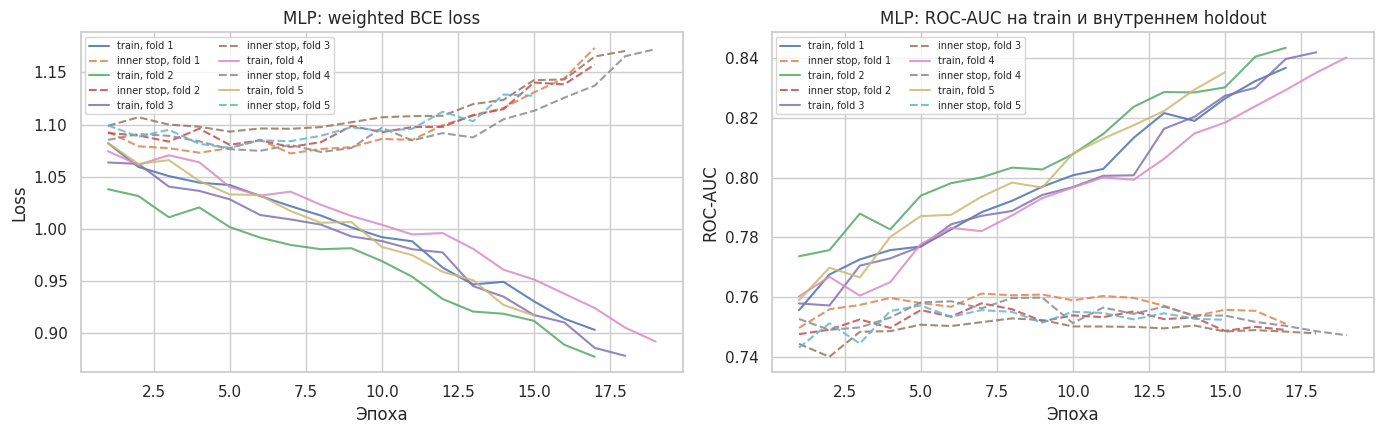

,n_features
fold,
1,300
2,300
3,300
4,300
5,300


Cross-fitted OOF blend: ROC-AUC=0.79299; веса для test={'LightGBM': np.float64(0.08), 'CatBoost': np.float64(0.9), 'MLP': np.float64(0.020000000000000018)}


,fold,LightGBM,CatBoost,MLP,roc_auc,pr_auc,brier,accuracy_05,f1_05
0,1,0.120000,0.860000,0.020000,0.79241,0.28726,0.06555,0.920232,0.090134
1,2,0.060000,0.920000,0.020000,0.79153,0.28949,0.06548,0.920214,0.091801
2,3,0.080000,0.900000,0.020000,0.79363,0.28795,0.06549,0.919775,0.089332
3,4,0.080000,0.900000,0.020000,0.79438,0.29090,0.06539,0.920653,0.087509
4,5,0.080000,0.900000,0.020000,0.79349,0.29425,0.06520,0.920198,0.089087


Ablation: Без бюро; признаков=929
[100]	valid_0's auc: 0.740083	valid_0's binary_logloss: 0.256871
[200]	valid_0's auc: 0.74781	valid_0's binary_logloss: 0.25497
[300]	valid_0's auc: 0.75242	valid_0's binary_logloss: 0.253736
[400]	valid_0's auc: 0.752171	valid_0's binary_logloss: 0.256233
[500]	valid_0's auc: 0.740413	valid_0's binary_logloss: 0.271703
[600]	valid_0's auc: 0.735339	valid_0's binary_logloss: 0.28204
[700]	valid_0's auc: 0.734424	valid_0's binary_logloss: 0.290602
[100]	valid_0's auc: 0.744405	valid_0's binary_logloss: 0.256908
[200]	valid_0's auc: 0.755523	valid_0's binary_logloss: 0.253733
[300]	valid_0's auc: 0.760214	valid_0's binary_logloss: 0.253859
[400]	valid_0's auc: 0.761479	valid_0's binary_logloss: 0.255564
[500]	valid_0's auc: 0.761582	valid_0's binary_logloss: 0.257532
[600]	valid_0's auc: 0.760496	valid_0's binary_logloss: 0.260819
[100]	valid_0's auc: 0.740684	valid_0's binary_logloss: 0.257488
[200]	valid_0's auc: 0.751494	valid_0's binary_logloss: 0.25

,model,fold,seconds,roc_auc,pr_auc,brier,accuracy_05,f1_05
0,LightGBM,1,35.6,0.76679,0.25016,0.06742,0.919256,0.048659
1,LightGBM,2,32.9,0.77720,0.26884,0.06669,0.919564,0.016696
2,LightGBM,3,32.4,0.77276,0.26148,0.06707,0.919645,0.012785
3,LightGBM,4,67.5,0.78095,0.26247,0.06683,0.919580,0.078614
4,LightGBM,5,31.7,0.77580,0.27161,0.06666,0.919434,0.009198


...

LightGBM OOF ROC-AUC=0.77843
Ablation: Без платёжной истории; признаков=1189
[100]	valid_0's auc: 0.689765	valid_0's binary_logloss: 0.267698
[200]	valid_0's auc: 0.740866	valid_0's binary_logloss: 0.253603
[300]	valid_0's auc: 0.751873	valid_0's binary_logloss: 0.250237
[400]	valid_0's auc: 0.752553	valid_0's binary_logloss: 0.250797
[500]	valid_0's auc: 0.754874	valid_0's binary_logloss: 0.250229
[600]	valid_0's auc: 0.757521	valid_0's binary_logloss: 0.250106
[700]	valid_0's auc: 0.757437	valid_0's binary_logloss: 0.250968
[100]	valid_0's auc: 0.745029	valid_0's binary_logloss: 0.25383
[200]	valid_0's auc: 0.753784	valid_0's binary_logloss: 0.250913
[300]	valid_0's auc: 0.757798	valid_0's binary_logloss: 0.249897
[400]	valid_0's auc: 0.759004	valid_0's binary_logloss: 0.250763
[500]	valid_0's auc: 0.75854	valid_0's binary_logloss: 0.251473
[600]	valid_0's auc: 0.749867	valid_0's binary_logloss: 0.252852
[700]	valid_0's auc: 0.748361	valid_0's binary_logloss: 0.254082
[100]	valid_0's

,model,fold,seconds,roc_auc,pr_auc,brier,accuracy_05,f1_05
0,LightGBM,1,45.0,0.76160,0.25148,0.06747,0.919679,0.044857
1,LightGBM,2,41.5,0.77429,0.26124,0.06687,0.919645,0.031740
2,LightGBM,3,39.4,0.77450,0.26515,0.06681,0.919807,0.024139
3,LightGBM,4,48.0,0.77924,0.26623,0.06663,0.919986,0.057460
4,LightGBM,5,41.9,0.77414,0.26887,0.06662,0.919612,0.029065


LightGBM OOF ROC-AUC=0.77259


,variant,n_features,roc_auc,pr_auc,delta_roc_auc_vs_full
0,Полная матрица,1476,0.77955,0.27174,+0.00000
1,Без прошлых заявок,987,0.77843,0.27130,-0.00112
2,Без бюро,929,0.77355,0.25861,-0.00599
3,Без платёжной истории,1189,0.77259,0.26151,-0.00696


,variant,n_features,roc_auc,pr_auc,delta_roc_auc_vs_full
0,Полная матрица,1476,0.77955,0.27174,+0.00000
1,Без прошлых заявок,987,0.77843,0.27130,-0.00112
2,Без бюро,929,0.77355,0.25861,-0.00599
3,Без платёжной истории,1189,0.77259,0.26151,-0.00696


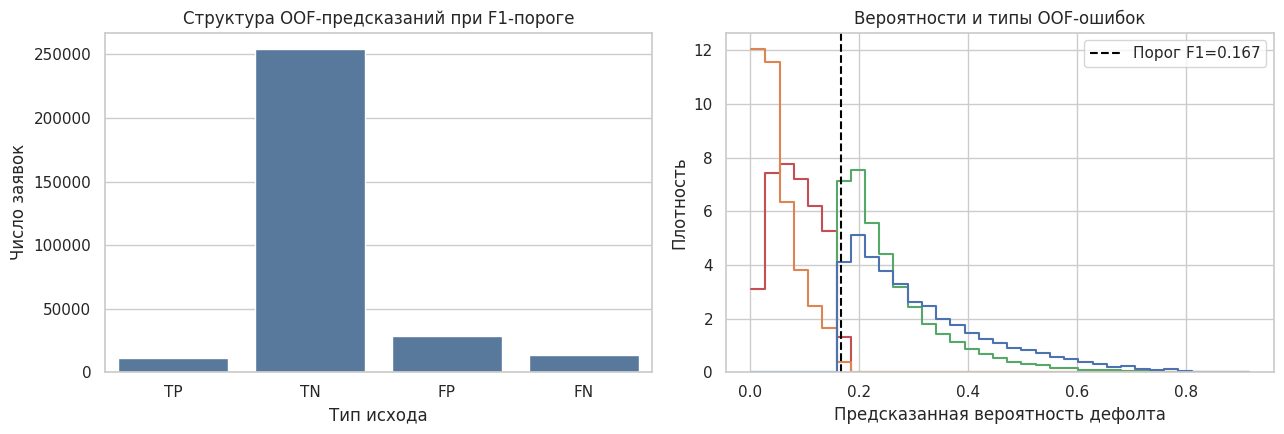

,error_type,n,share,mean_probability,default_rate,median_age,median_credit_to_income,median_ext_source
0,TP,11201,3.64%,0.316,100.00%,36.5,3.19,0.296
1,TN,254527,82.77%,0.054,0.00%,44.3,3.28,0.551
2,FP,28159,9.16%,0.262,0.00%,36.4,3.18,0.320
3,FN,13624,4.43%,0.086,100.00%,41.6,3.32,0.482


,error_type,probability,target,age_years,credit_to_income,ext_source_mean
213069,FP,0.167,0,29.9,7.09,0.279
255837,FP,0.167,0,36.4,6.39,0.451
217935,FP,0.167,0,23.1,2.84,0.280
264022,FP,0.167,0,23.7,4.61,0.401
158054,FP,0.167,0,57.5,5.46,0.335
197990,FP,0.167,0,53.2,4.04,0.357
266177,FP,0.167,0,62.8,6.95,0.285
197560,FP,0.167,0,23.5,2.22,0.263
184906,FP,0.167,0,36.1,6.19,0.447
43077,FP,0.167,0,22.3,5.09,0.270


,error_type,n,share,mean_probability,default_rate,median_age,median_credit_to_income,median_ext_source
0,TP,11201,3.64%,0.3158,100.00%,36.5,3.19,0.296
1,TN,254527,82.77%,0.0540,0.00%,44.3,3.28,0.551
2,FP,28159,9.16%,0.2617,0.00%,36.4,3.18,0.320
3,FN,13624,4.43%,0.0863,100.00%,41.6,3.32,0.482


,SK_ID_CURR,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,DAYS_BIRTH,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,target,probability,prediction,error_type,age_years,credit_to_income,ext_source_mean,distance_to_threshold
213069,346911,"135,000.0000","956,574.0000","48,969.0000",-10939,NaN,0.2788,NaN,0,0.1666,1,FP,29.9493,7.0857,0.2788,0.0000
255837,396039,"225,000.0000","1,436,850.0000","42,142.5000",-13285,0.3322,0.4216,0.5989,0,0.1666,1,FP,36.3723,6.3860,0.4509,0.0000
217935,352498,"112,500.0000","319,500.0000","17,329.5000",-8424,NaN,0.4326,0.1277,0,0.1666,1,FP,23.0637,2.8400,0.2801,0.0000
264022,405736,"90,000.0000","414,792.0000","22,630.5000",-8654,NaN,0.4907,0.3108,0,0.1666,1,FP,23.6934,4.6088,0.4007,0.0000
158054,283222,"112,500.0000","614,223.0000","24,034.5000",-20984,NaN,0.5136,0.1566,0,0.1666,1,FP,57.4511,5.4598,0.3351,0.0000
197990,329555,"135,000.0000","545,040.0000","26,640.0000",-19441,NaN,0.0934,0.6212,0,0.1666,1,FP,53.2266,4.0373,0.3573,0.0000
266177,408337,"94,500.0000","656,811.0000","21,105.0000",-22926,NaN,0.3000,0.2707,0,0.1666,1,FP,62.7680,6.9504,0.2854,0.0000
197560,329053,"81,000.0000","180,000.0000","9,000.0000",-8596,0.2020,0.3954,0.1907,0,0.1666,1,FP,23.5346,2.2222,0.2627,0.0000
184906,314339,"112,500.0000","696,150.0000","33,619.5000",-13185,0.3577,0.5977,0.3842,0,0.1666,1,FP,36.0986,6.1880,0.4465,0.0000
43077,149866,"67,500.0000","343,800.0000","16,852.5000",-8141,0.2494,0.2561,0.3047,0,0.1666,1,FP,22.2888,5.0933,0.2700,0.0000


,model,seconds,roc_auc,pr_auc,brier,accuracy_05,f1_05
3,OOF blend,216.2,0.79299,0.28966,0.06542,0.9202,0.0896
1,CatBoost (история),1024.9,0.79279,0.28916,0.06546,0.9202,0.0920
0,LightGBM (история),220.4,0.77955,0.27174,0.06651,0.9197,0.0223
4,LightGBM (только анкета),36.5,0.76741,0.25278,0.06732,0.9197,0.0466
2,MLP (история),198.0,0.75903,0.24024,0.19482,0.6912,0.2671
5,Логистическая регрессия,653.0,0.75126,0.23164,0.20195,0.6880,0.2612
6,Одиночное дерево,57.4,0.72776,0.20338,0.20829,0.6772,0.2476


Создан submission: /home/vmuser/Загрузки/04_home_credit_scoring/submissions/submission_oof_blend.csv; ROC-AUC OOF blend=0.79299


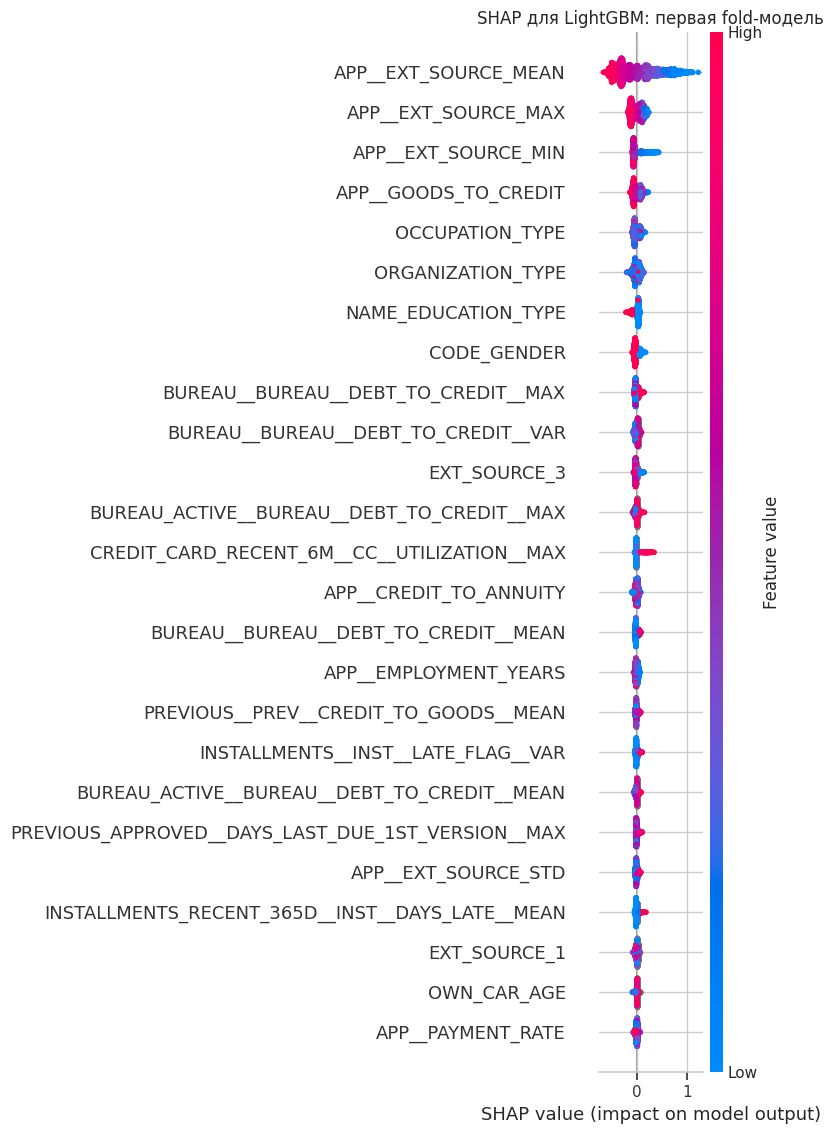

,dimension,group,n,default_rate,positive_rate,tpr,fpr,fnr,roc_auc,pr_auc,brier
1,CODE_GENDER,M,105059,10.14%,18.18%,51.53%,14.42%,48.47%,0.78324,0.31398,0.08006
0,CODE_GENDER,F,202448,7.00%,10.01%,40.30%,7.73%,59.70%,0.79248,0.27036,0.05783
2,age_group,"[18, 25)",12233,12.29%,26.63%,56.12%,22.50%,43.88%,0.74252,0.29492,0.09807
6,age_group,"[55, 65)",60522,5.42%,5.65%,27.67%,4.39%,72.33%,0.76238,0.20015,0.04732
7,age_group,"[65, 100)",7876,3.66%,1.61%,11.46%,1.24%,88.54%,0.76622,0.15001,0.03327
3,age_group,"[25, 35)",72429,10.66%,20.14%,54.23%,16.07%,45.77%,0.78421,0.32402,0.08340
5,age_group,"[45, 55)",70190,7.05%,10.00%,40.52%,7.69%,59.48%,0.79140,0.27975,0.05788
4,age_group,"[35, 45)",84261,8.41%,12.99%,45.52%,10.01%,54.48%,0.79806,0.30074,0.06752


Сохранён финальный отчётный результат: /home/vmuser/Загрузки/04_home_credit_scoring/reports/final_results.json


In [46]:
if RUN_FULL_COMPETITIVE_EXPERIMENT:
    torch.manual_seed(RANDOM_STATE)
    torch.cuda.manual_seed_all(RANDOM_STATE)
    print(f'LightGBM device_type={LGBM_DEVICE_TYPE}; n_jobs={LGBM_N_JOBS}')

    # Полный pipeline: матрица построена выше, leakage_checks уже должен быть пройден.
    tuning_started = perf_counter()
    lgbm_best_params = tune_lightgbm(X, target, categorical_columns, trials=FULL_OPTUNA_TRIALS)
    lgbm_tuning_seconds = perf_counter() - tuning_started
    print(f'Optuna: {lgbm_tuning_seconds / 60:.1f} мин.')
    lgbm_oof, lgbm_test, lgbm_models, lgbm_folds, lgbm_metrics = lightgbm_oof_predictions(
        X, X_test, target, categorical_columns, lgbm_best_params,
    )
    cat_oof, cat_test, cat_models, cat_folds, cat_metrics = catboost_oof_predictions(
        X, X_test, target, categorical_columns,
    )
    mlp_oof, mlp_test, mlp_models, mlp_folds, mlp_metrics, mlp_history = mlp_oof_predictions(
        X, X_test, target, categorical_columns, feature_limit=300,
    )

    prediction_map = {'LightGBM': lgbm_oof, 'CatBoost': cat_oof, 'MLP': mlp_oof}
    blend_started = perf_counter()
    blend_weights, blend_oof, blend_folds = choose_cross_fitted_blend(
        target, prediction_map
    )
    blend_seconds = perf_counter() - blend_started
    blend_metrics = score_predictions(target, blend_oof)
    blend_test = sum(blend_weights[name] * prediction for name, prediction in {
        'LightGBM': lgbm_test, 'CatBoost': cat_test, 'MLP': mlp_test,
    }.items())


    # Ablation и error analysis используют исключительно OOF-прогнозы и матрицу.
    ablation_results = pd.DataFrame()
    if RUN_ABLATION_STUDY:
        ablation_results = feature_ablation_study(
            X, X_test, target, categorical_columns, lgbm_best_params, lgbm_metrics,
        )
        display(ablation_results.style.format({
            'roc_auc': '{:.5f}', 'pr_auc': '{:.5f}', 'delta_roc_auc_vs_full': '{:+.5f}',
        }))

    error_summary = pd.DataFrame()
    uncertain_oof_errors = pd.DataFrame()
    if RUN_ERROR_ANALYSIS:
        error_summary, uncertain_oof_errors = oof_error_analysis(
            application_train, target, blend_oof, operating_threshold_from_oof(target, blend_oof),
        )
        display(error_summary.style.format({
            'share': '{:.2%}', 'mean_probability': '{:.4f}',
            'default_rate': '{:.2%}', 'median_age': '{:.1f}',
            'median_credit_to_income': '{:.2f}', 'median_ext_source': '{:.3f}',
        }))
        display(uncertain_oof_errors)

    comparison_rows = [
        {'model': 'LightGBM (история)', 'seconds': lgbm_folds['seconds'].sum(), **lgbm_metrics},
        {'model': 'CatBoost (история)', 'seconds': cat_folds['seconds'].sum(), **cat_metrics},
        {'model': 'MLP (история)', 'seconds': mlp_folds['seconds'].sum(), **mlp_metrics},
        {'model': 'OOF blend', 'seconds': blend_seconds, **blend_metrics},
    ]
    if 'application_only_baseline_results' in globals():
        comparison_rows.append({
            'model': 'LightGBM (только анкета)', 'seconds': application_only_baseline_results['seconds'].sum(),
            **application_lgbm_metrics,
        })
    for model_name, metrics in globals().get('classic_metrics', {}).items():
        elapsed = application_classic_baseline_results.loc[application_classic_baseline_results['model'].eq(model_name), 'seconds'].sum()
        comparison_rows.append({'model': model_name, 'seconds': elapsed, **metrics})
    comparison = pd.DataFrame(comparison_rows).sort_values('roc_auc', ascending=False)
    display(comparison.style.format({'roc_auc': '{:.5f}', 'pr_auc': '{:.5f}', 'brier': '{:.5f}', 'accuracy_05': '{:.4f}', 'f1_05': '{:.4f}', 'seconds': '{:.1f}'}).set_caption('Сравнение моделей по одинаковой 5-fold OOF-валидации'))

    submission = pd.DataFrame({'SK_ID_CURR': test_matrix['SK_ID_CURR'], 'TARGET': blend_test.clip(0, 1)})
    assert len(submission) == len(test_matrix) and submission['SK_ID_CURR'].is_unique
    assert submission['TARGET'].between(0, 1).all()
    submission_path = SUBMISSIONS_DIR / 'submission_oof_blend.csv'
    submission.to_csv(submission_path, index=False)
    print(f'Создан submission: {submission_path}; ROC-AUC OOF blend={blend_metrics["roc_auc"]:.5f}')

    fairness_results = pd.DataFrame()
    if RUN_SHAP_AND_FAIRNESS:
        shap_analysis(lgbm_models, X)
        fairness_results = fairness_table(application_train, target, blend_oof)
        display(fairness_results.style.format({'default_rate': '{:.2%}', 'positive_rate': '{:.2%}', 'tpr': '{:.2%}', 'fpr': '{:.2%}', 'fnr': '{:.2%}', 'roc_auc': '{:.5f}', 'pr_auc': '{:.5f}', 'brier': '{:.5f}'}))

    report_payload = {
        'random_state': RANDOM_STATE,
        'n_splits': N_SPLITS,
        'n_train_rows': len(X),
        'n_test_rows': len(X_test),
        'n_features': X.shape[1],
        'categorical_features': len(categorical_columns),
        'comparison': json.loads(comparison.to_json(orient='records')),
        'lgbm_best_params': lgbm_best_params,
        'lgbm_tuning_seconds': float(lgbm_tuning_seconds),
        'blend_seconds': float(blend_seconds),
        'blend_weights': {name: float(weight) for name, weight in blend_weights.items()},
        'blend_folds': json.loads(blend_folds.to_json(orient='records')),
        'feature_build_audit': json.loads(feature_build_audit.to_json(orient='records')),
        'source_coverage': json.loads(source_coverage.to_json(orient='records')),
        'leakage_audit': json.loads(leakage_checks.to_json(orient='records')),
        'fairness': json.loads(fairness_results.to_json(orient='records')),
        'ablation': json.loads(ablation_results.to_json(orient='records')),
        'error_analysis': json.loads(error_summary.to_json(orient='records')),
        'submission_path': str(submission_path),
    }
    results_path = REPORTS_DIR / 'final_results.json'
    results_path.write_text(json.dumps(report_payload, ensure_ascii=False, indent=2), encoding='utf-8')
    print(f'Сохранён финальный отчётный результат: {results_path}')
else:
    print('Финальный запуск отключён в конфигурации первой ячейки.')

## 11. Результаты

После полного запуска здесь собирается одна таблица со всеми моделями. До запуска готовых цифр не подставляю: итоговые выводы должны строиться только по фактически полученным OOF-метрикам.

Время в таблице — непосредственно 5-fold обучение соответствующей модели. Время Optuna сохраняется отдельно, потому что это стоимость подбора гиперпараметров, а не обучение одного финального варианта. Для `OOF blend` считается только время подбора весов; обучение базовых моделей уже учтено в их собственных строках.

In [47]:
if RUN_FULL_COMPETITIVE_EXPERIMENT:
    best_row = comparison.iloc[0]
    lgbm_row = comparison.loc[comparison['model'].eq('LightGBM (история)')].iloc[0]
    blend_row = comparison.loc[comparison['model'].eq('OOF blend')].iloc[0]
    classic_rows = comparison.loc[
        comparison['model'].isin(['Логистическая регрессия', 'Одиночное дерево'])
    ]
    best_classic_auc = classic_rows['roc_auc'].max() if not classic_rows.empty else np.nan
    fold_std = lgbm_folds['roc_auc'].std(ddof=1)

    lines = [
        f"**Лучший результат:** {best_row['model']} с ROC-AUC {best_row['roc_auc']:.5f} и PR-AUC {best_row['pr_auc']:.5f}.",
        f"**Стабильность:** стандартное отклонение ROC-AUC LightGBM по фолдам равно {fold_std:.5f}. Небольшие приросты стоит сравнивать с этим разбросом.",
        f"**Ансамбль:** OOF blend {'улучшил' if blend_row['roc_auc'] >= lgbm_row['roc_auc'] else 'не улучшил'} LightGBM на {blend_row['roc_auc'] - lgbm_row['roc_auc']:+.5f} ROC-AUC.",
    ]

    application_lgbm_rows = comparison.loc[
        comparison['model'].eq('LightGBM (только анкета)')
    ]
    if not application_lgbm_rows.empty:
        application_lgbm_auc = application_lgbm_rows.iloc[0]['roc_auc']
        history_delta = lgbm_row['roc_auc'] - application_lgbm_auc
        lines.append(
            f"**Польза истории:** при одной и той же модели добавление исторических таблиц "
            f"изменило ROC-AUC на {history_delta:+.5f} относительно варианта только по текущей заявке."
        )

    if not np.isnan(best_classic_auc):
        lines.append(
            f"**Простые модели:** лучший из линейного baseline и одиночного дерева "
            f"отстаёт от LightGBM с историей на {lgbm_row['roc_auc'] - best_classic_auc:+.5f} ROC-AUC."
        )

    lines.append(
        "**Почему результаты могут отличаться:** бустинги умеют использовать нелинейные взаимодействия "
        "между нагрузкой, внешними скорингами и историей. Логистическая регрессия ограничена "
        "аддитивной формой, а одиночное дерево — одним набором разбиений."
    )

    if RUN_ABLATION_STUDY and not ablation_results.empty:
        variants = ablation_results.loc[
            ablation_results['variant'].ne('Полная матрица')
        ].copy()
        strongest_drop = variants.sort_values('delta_roc_auc_vs_full').iloc[0]
        delta = strongest_drop['delta_roc_auc_vs_full']
        if delta < 0:
            lines.append(
                f"**Ablation:** сильнее всего качество снизилось в варианте «{strongest_drop['variant']}» "
                f"({delta:+.5f} ROC-AUC относительно полной матрицы)."
            )
        else:
            lines.append(
                "**Ablation:** исключение проверенных крупных групп признаков не дало заметного падения "
                "ROC-AUC; вклад истории в таком случае нужно интерпретировать осторожно."
            )

    if RUN_ERROR_ANALYSIS and not error_summary.empty:
        fp = error_summary.loc[error_summary['error_type'].eq('FP'), 'n'].sum()
        fn = error_summary.loc[error_summary['error_type'].eq('FN'), 'n'].sum()
        lines.append(
            f"**Ошибки:** при выбранном OOF-пороге FP={int(fp):,}, FN={int(fn):,}. "
            "Пограничные случаи и их профили показаны выше."
        )

    if RUN_SHAP_AND_FAIRNESS and not fairness_results.empty:
        fairness_parts = []
        for dimension, group in fairness_results.groupby('dimension'):
            fairness_parts.append(
                f"{dimension}: ΔTPR={group['tpr'].max() - group['tpr'].min():.3f}, "
                f"ΔFPR={group['fpr'].max() - group['fpr'].min():.3f}"
            )
        lines.append(
            "**Fairness-диагностика:** разброс чувствительности и ложноположительных срабатываний "
            "между группами составил " + "; ".join(fairness_parts) +
            ". Это описательные различия, а не доказательство дискриминации."
        )

    display(
        Markdown(
            '### Содержательные выводы после OOF-валидации\n\n'
            + '\n\n'.join(f'- {line}' for line in lines)
        )
    )
else:
    print('Итоговые выводы появятся после RUN_FULL_COMPETITIVE_EXPERIMENT=True.')


### Содержательные выводы после OOF-валидации

- **Лучший результат:** OOF blend с ROC-AUC 0.79299 и PR-AUC 0.28966.

- **Стабильность:** стандартное отклонение ROC-AUC LightGBM по фолдам равно 0.00446. Небольшие приросты стоит сравнивать с этим разбросом.

- **Ансамбль:** OOF blend улучшил LightGBM на +0.01344 ROC-AUC.

- **Польза истории:** при одной и той же модели добавление исторических таблиц изменило ROC-AUC на +0.01213 относительно варианта только по текущей заявке.

- **Простые модели:** лучший из линейного baseline и одиночного дерева отстаёт от LightGBM с историей на +0.02828 ROC-AUC.

- **Почему результаты могут отличаться:** бустинги умеют использовать нелинейные взаимодействия между нагрузкой, внешними скорингами и историей. Логистическая регрессия ограничена аддитивной формой, а одиночное дерево — одним набором разбиений.

- **Ablation:** сильнее всего качество снизилось в варианте «Без платёжной истории» (-0.00696 ROC-AUC относительно полной матрицы).

- **Ошибки:** при выбранном OOF-пороге FP=28,159, FN=13,624. Пограничные случаи и их профили показаны выше.

- **Fairness-диагностика:** разброс чувствительности и ложноположительных срабатываний между группами составил CODE_GENDER: ΔTPR=0.112, ΔFPR=0.067; age_group: ΔTPR=0.447, ΔFPR=0.213. Это описательные различия, а не доказательство дискриминации.

## 12. Выводы

Финальные выводы формируются только после полного запуска. Основные вопросы здесь четыре: насколько полезна подробная кредитная история по сравнению с той же LightGBM на текущей заявке, стабилен ли результат между фолдами, помогает ли ансамбль и какие группы признаков/клиентов дают основные ошибки.

Отдельно фиксирую ограничение постановки: `EXT_SOURCE_*` уже присутствуют в основной таблице и могут содержать внешнюю скоринговую информацию, поэтому baseline по `application_train` — это прокси отсутствия **детальной истории Home Credit**, а не доказанный сценарий полного отсутствия любой кредитной информации.